In [ ]:
!pip install -q \
langgraph \
langchain \
langchain-core \
langchain-google-genai \
pymupdf \
python-dotenv

import os
import fitz

from google.colab import files

from langchain_google_genai import ChatGoogleGenerativeAI

os.environ["GOOGLE_API_KEY"] = "YOUR_GOOGLE_API_KEY_HERE"


In [ ]:
### Testing
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

response = llm.invoke(
    "Say hello and tell me you are working."
)

print(response.content)

Hello! I am working.


In [ ]:
uploaded = files.upload()

Saving grade12math.pdf to grade12math.pdf


In [ ]:
import os

for file in os.listdir():
    print(file)

.config
grade12math.pdf
sample_data
=1.4.7


In [ ]:
pdf_path = "grade12math.pdf"

doc = fitz.open(pdf_path)

print("Pages:", len(doc))

Pages: 667


In [ ]:
text = ""

for page_num in range(min(3, len(doc))):
    page = doc[page_num]
    text += page.get_text()

print(text[:3000])

Chapter 1
Functions and Models
M
O
D
E
L
L
I
N
G
•
M
A
T
H
•
One of the main reasons that mathematics is so interesting is that it can
be applied to the world around us. First, the simplest features of some
realistic situation are described using mathematics. Then, operations are
performed on the mathematical description so that predictions about the
future are obtained. The predictions are compared with observations to
test the validity of the mathematical description. Modifications are made
to the description, if necessary, and the whole process is repeated. This
process, called mathematical modelling, has produced numerous useful
descriptions of our world.
In this chapter, we review functions, which are used extensively as
mathematical models, and we explore many mathematical models, which
describe such diverse situations as the difficulty of a bicycle ride, the
shape of a roller-coaster ride, and the use of fertilizer in a cherry orchard.
Determine, through investigation, using gra

In [ ]:
### first mini-AI test Ask Gemini About PDF
prompt = f"""
You are a math teacher.

Summarize this textbook content.

TEXT:

{text[:5000]}
"""

response = llm.invoke(prompt)

print(response.content)

Alright class, welcome to Chapter 1: **Functions and Models**!

This chapter is all about understanding how mathematics helps us make sense of the world around us. We're going to dive into the fascinating process called **mathematical modeling**.

Think of it this way: we take a real-world situation – maybe how a roller coaster is designed, or how fertilizer affects a cherry orchard – and we translate its simplest features into mathematical language. Then, we use mathematical operations to make predictions about what might happen in the future. We test those predictions against observations, and if our model isn't quite right, we adjust it and try again. This iterative process is incredibly powerful and has given us countless insights into our world.

In this chapter, we'll start by **reviewing functions**, which are the fundamental building blocks for most mathematical models. You'll learn to:

*   **Investigate polynomial functions** using graphing calculators or software to understa

In [ ]:
### create the future state
state = {
    "pdf_path": pdf_path,
    "raw_text": text
}

print(state.keys())

dict_keys(['pdf_path', 'raw_text'])


In [ ]:
from typing import TypedDict


class TutorState(TypedDict):
    pdf_path: str
    raw_text: str
    course_structure: dict

In [ ]:
state = {
    "pdf_path": pdf_path,
    "raw_text": text,
    "course_structure": {}
}

state

{'pdf_path': 'grade12math.pdf',
 'raw_text': 'Chapter 1\nFunctions and Models\nM\nO\nD\nE\nL\nL\nI\nN\nG\n•\nM\nA\nT\nH\n•\nOne of the main reasons that mathematics is so interesting is that it can\nbe applied to the world around us. First, the simplest features of some\nrealistic situation are described using mathematics. Then, operations are\nperformed on the mathematical description so that predictions about the\nfuture are obtained. The predictions are compared with observations to\ntest the validity of the mathematical description. Modifications are made\nto the description, if necessary, and the whole process is repeated. This\nprocess, called mathematical modelling, has produced numerous useful\ndescriptions of our world.\nIn this chapter, we review functions, which are used extensively as\nmathematical models, and we explore many mathematical models, which\ndescribe such diverse situations as the difficulty of a bicycle ride, the\nshape of a roller-coaster ride, and the use of 

In [ ]:
### pdf parser agent
import json


def pdf_parser_agent(state):

    raw_text = state["raw_text"]

    prompt = f"""
You are a PDF Parser Agent.

Analyze this math textbook.

Identify:

1. Chapters
2. Major sections
3. Main topics

Return JSON only.

Example:

{{
    "chapters":[
        {{
            "chapter":"Functions",
            "sections":[
                "Domain and Range",
                "Transformations"
            ]
        }}
    ]
}}

TEXT:

{raw_text[:12000]}
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
### test agent
result = pdf_parser_agent(state)

print(result)

```json
{
    "chapters": [
        {
            "chapter": "Functions and Models",
            "sections": [
                "Mathematical Modelling",
                "Properties of Polynomial Functions (using graphing tools)",
                "Absolute Value Notation (for intervals and distances)",
                "Key Features of Mathematical Models (using differential calculus)",
                "Comparing Mathematical Models with Applications",
                "Predicting Future Behaviour from Mathematical Models",
                "Analyzing Mathematical Models (using differential calculus)",
                "Communicating Mathematical Findings"
            ]
        }
    ]
}
```


In [ ]:
import json
def clean_json(text):
  text = text.replace("```json", "")
  text = text.replace("```", "")
  return json.loads(text)

In [ ]:
course_structure = clean_json(result)

course_structure

{'chapters': [{'chapter': 'Functions and Models',
   'sections': ['Mathematical Modelling',
    'Properties of Polynomial Functions (using graphing tools)',
    'Absolute Value Notation (for intervals and distances)',
    'Key Features of Mathematical Models (using differential calculus)',
    'Comparing Mathematical Models with Applications',
    'Predicting Future Behaviour from Mathematical Models',
    'Analyzing Mathematical Models (using differential calculus)',
    'Communicating Mathematical Findings']}]}

In [ ]:
print(len(state["raw_text"]))

1919


In [ ]:
pdf_path = "grade12math.pdf"

doc = fitz.open(pdf_path)

print("Pages:", len(doc))

for i in range(min(10, len(doc))):
    page = doc[i]
    page_text = page.get_text()

    print(f"\nPage {i+1}")
    print("Characters:", len(page_text))

Pages: 667

Page 1
Characters: 0

Page 2
Characters: 1919

Page 3
Characters: 0

Page 4
Characters: 2588

Page 5
Characters: 1850

Page 6
Characters: 1898

Page 7
Characters: 2142

Page 8
Characters: 1782

Page 9
Characters: 1949

Page 10
Characters: 1267


In [ ]:
pdf_path = "grade12math.pdf"

doc = fitz.open(pdf_path)

text = ""

for page_num in range(min(50, len(doc))):
    page = doc[page_num]
    text += page.get_text()

print("Characters:", len(text))

Characters: 92100


In [ ]:
!pip install -q \
langchain-text-splitters \
langchain-google-genai

import os
import fitz
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

pdf_path = "grade12math.pdf"

doc = fitz.open(pdf_path)

print("Total pages:", len(doc))

all_page_docs = []

for page_index in range(len(doc)):
    page = doc[page_index]
    page_text = page.get_text()

    if page_text.strip():
        page_doc = Document(
            page_content=page_text,
            metadata={
                "source": pdf_path,
                "page": page_index + 1
            }
        )

        all_page_docs.append(page_doc)

print("Pages with text:", len(all_page_docs))
print(all_page_docs[0].metadata)

print(all_page_docs[0].page_content[:1000])

total_chars = sum(
    len(doc.page_content)
    for doc in all_page_docs
)

print("Total characters extracted:", total_chars)

Total pages: 667
Pages with text: 663
{'source': 'grade12math.pdf', 'page': 2}
Chapter 1
Functions and Models
M
O
D
E
L
L
I
N
G
•
M
A
T
H
•
One of the main reasons that mathematics is so interesting is that it can
be applied to the world around us. First, the simplest features of some
realistic situation are described using mathematics. Then, operations are
performed on the mathematical description so that predictions about the
future are obtained. The predictions are compared with observations to
test the validity of the mathematical description. Modifications are made
to the description, if necessary, and the whole process is repeated. This
process, called mathematical modelling, has produced numerous useful
descriptions of our world.
In this chapter, we review functions, which are used extensively as
mathematical models, and we explore many mathematical models, which
describe such diverse situations as the difficulty of a bicycle ride, the
shape of a roller-coaster ride, and the use

In [ ]:
total_chars = sum(
    len(page_doc.page_content)
    for page_doc in all_page_docs
)

print("Total characters extracted:", total_chars)

Total characters extracted: 1327801


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200,
    chunk_overlap=200,
    length_function=len,
    separators=[
        "\n\n",
        "\n",
        ". ",
        " ",
        ""
    ]
)

book_chunks = text_splitter.split_documents(all_page_docs)

print("Total chunks:", len(book_chunks))

Total chunks: 1553


In [ ]:
print(book_chunks[0].metadata)

print(book_chunks[0].page_content[:1000])

{'source': 'grade12math.pdf', 'page': 2}
Chapter 1
Functions and Models
M
O
D
E
L
L
I
N
G
•
M
A
T
H
•
One of the main reasons that mathematics is so interesting is that it can
be applied to the world around us. First, the simplest features of some
realistic situation are described using mathematics. Then, operations are
performed on the mathematical description so that predictions about the
future are obtained. The predictions are compared with observations to
test the validity of the mathematical description. Modifications are made
to the description, if necessary, and the whole process is repeated. This
process, called mathematical modelling, has produced numerous useful
descriptions of our world.
In this chapter, we review functions, which are used extensively as
mathematical models, and we explore many mathematical models, which
describe such diverse situations as the difficulty of a bicycle ride, the
shape of a roller-coaster ride, and the use of fertilizer in a cherry orchard.
De

In [ ]:
for i in range(5):
    print("Chunk:", i)
    print("Page:", book_chunks[i].metadata["page"])
    print(book_chunks[i].page_content[:300])
    print("-" * 80)

Chunk: 0
Page: 2
Chapter 1
Functions and Models
M
O
D
E
L
L
I
N
G
•
M
A
T
H
•
One of the main reasons that mathematics is so interesting is that it can
be applied to the world around us. First, the simplest features of some
realistic situation are described using mathematics. Then, operations are
performed on the ma
--------------------------------------------------------------------------------
Chunk: 1
Page: 2
software, various properties of the graphs of polynomial functions.
Describe intervals and distances, using absolute value notation.
Determine the key features of a mathematical model of an application
drawn from the natural or social sciences, using the techniques of 
differential calculus.
Compare
--------------------------------------------------------------------------------
Chunk: 2
Page: 4
4 MHR Chapter 1
Review of Prerequisite Skills
Review of Prerequisite Skills
1.
Evaluating functions If f(x)  x
3  x
2  2x  3,
find
a)
f(0)
b)
f(1)
c)
d)
f(1)
e)
f(0.1)
f)
f(a)
g)
f

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001"
)

In [ ]:
vector_store = InMemoryVectorStore(
    embedding=embeddings
)

In [ ]:
batch_size = 50

for start_index in range(0, len(book_chunks), batch_size):
    end_index = start_index + batch_size

    batch = book_chunks[start_index:end_index]

    vector_store.add_documents(batch)

    print(
        "Added chunks",
        start_index,
        "to",
        start_index + len(batch)
    )

Added chunks 0 to 50


GoogleGenerativeAIError: Error embedding content (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. ', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}]}}

In [ ]:
from typing import TypedDict

class TutorState(TypedDict):
    pdf_path: str
    raw_text: str

    course_structure: dict
    knowledge_map: dict

    current_concept: str
    lesson_plan: str

In [ ]:
state["current_concept"] = ""
state["lesson_plan"] = ""

In [ ]:
### build curriculumn agent

def curriculum_agent(state):

    knowledge_map = state["knowledge_map"]

    prompt = f"""
You are a Curriculum Agent.

Design a 25 minute lesson.

Choose ONE concept that should be taught first.

Return JSON only.

Format:

{{
    "current_concept":"...",
    "lesson_plan": [
        "Review",
        "Explanation",
        "Guided Practice",
        "Reflection"
    ]
}}

Knowledge Map:

{knowledge_map}
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
result = curriculum_agent(state)

print(result)

KeyError: 'knowledge_map'

In [ ]:
print(state.keys())

dict_keys(['pdf_path', 'raw_text', 'course_structure', 'current_concept', 'lesson_plan'])


In [ ]:
state["current_concept"] = "Mathematical Modelling"

print(state["current_concept"])

Mathematical Modelling


In [ ]:
### teaching agent

def teaching_agent(state):

    concept = state["current_concept"]

    prompt = f"""
You are a Grade 12 Math Tutor.

Teach this concept:

{concept}

Requirements:

1. Simple explanation.
2. Real-world example.
3. Visual analogy.
4. Common mistakes.
5. One practice question.

Use student-friendly language.
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
teaching_content = teaching_agent(state)

print(teaching_content)

Hey everyone! Your Grade 12 Math Tutor here, ready to dive into a super important and really cool concept: **Mathematical Modelling**.

Don't let the fancy name scare you! It's something you probably already do in your head without even realizing it.

---

### 1. Simple Explanation: What is Mathematical Modelling?

Imagine you have a real-world problem or situation – something happening around you. Maybe it's how fast a rumour spreads, how much money you'll save for a new phone, or how many people will show up to a school event.

**Mathematical modelling is simply using the language of math (equations, graphs, functions, statistics) to understand, describe, and predict what's happening in that real-world situation.**

Think of it as building a "math version" of a real-world problem. We take the messy, complicated reality, simplify it a bit, translate it into math, solve the math problem, and then translate the answer back to understand the real world better.

**Why do we do it?**
*   T

In [ ]:
state["teaching_content"] = teaching_content

In [ ]:
print(state.keys())

dict_keys(['pdf_path', 'raw_text', 'course_structure', 'current_concept', 'lesson_plan', 'teaching_content'])


In [ ]:
### quiz agent
def quiz_agent(state):

    concept = state["current_concept"]

    prompt = f"""
Create a short quiz for:

{concept}

Return:

1. Two multiple choice questions
2. One true/false question
3. One application question
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
quiz = quiz_agent(state)

print(quiz)

Here is a short quiz on Mathematical Modelling:

---

**Mathematical Modelling Quiz**

**Instructions:** Please answer all questions.

---

**1. Multiple Choice Questions**

1.  Which of the following best describes the primary goal of mathematical modelling?
    a) To find exact analytical solutions for complex equations.
    b) To represent real-world phenomena using mathematical concepts to gain understanding and make predictions.
    c) To automate all decision-making processes in business and science.
    d) To prove mathematical theorems using real-world data.

2.  In the process of mathematical modelling, what is the primary role of making assumptions?
    a) To ensure the model perfectly replicates all real-world complexities.
    b) To simplify the problem, making it tractable and allowing for the formulation of a mathematical representation.
    c) To eliminate the need for data collection and validation.
    d) To always lead to a unique and exact solution.

---

**2. True/F

In [ ]:
### Evaluation Agent
state["student_answer"] = ""
state["mastery_score"] = 0
state["evaluation_feedback"] = ""

In [ ]:
print(state.keys())

dict_keys(['pdf_path', 'raw_text', 'course_structure', 'current_concept', 'lesson_plan', 'teaching_content', 'student_answer', 'mastery_score', 'evaluation_feedback'])


In [ ]:
### Simulate Student Answer
state["student_answer"] = """
1. B
2. B
3. False

4.
a) Number of bacteria

b) Assume unlimited nutrients

c) This simplifies the model.
"""

In [ ]:
### evalutaion agent

import json

def evaluation_agent(state):

    quiz = state["quiz"]

    answer = state["student_answer"]

    prompt = f"""
You are an evaluator.

Evaluate the student's answer.

QUIZ:

{quiz}

STUDENT ANSWER:

{answer}

Return JSON only.

Format:

{{
  "mastery_score": 85,
  "feedback":"..."
}}
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
evaluation_result = evaluation_agent(state)

print(evaluation_result)

KeyError: 'quiz'

In [ ]:
state["quiz"] = quiz

print(state.keys())

dict_keys(['pdf_path', 'raw_text', 'course_structure', 'current_concept', 'lesson_plan', 'teaching_content', 'student_answer', 'mastery_score', 'evaluation_feedback', 'quiz'])


In [ ]:
evaluation_result = evaluation_agent(state)

print(evaluation_result)

```json
{
  "mastery_score": 92,
  "feedback": "The student has demonstrated a strong understanding of the core concepts in mathematical modelling. All multiple-choice and true/false questions were answered correctly, indicating a solid grasp of the primary goals, the role of assumptions, and the iterative nature of modelling.\n\nFor the application question (Q4):\n*   **Q4a (Key Variable):** Correctly identified 'Number of bacteria' as a key variable.\n*   **Q4b (Significant Assumption):** Correctly stated 'Assume unlimited nutrients' as a valid simplifying assumption.\n*   **Q4c (Explanation for Assumption):** The answer 'This simplifies the model' is correct but very brief. While it does simplify the model, a more comprehensive explanation would describe *how* it simplifies (e.g., by reducing the number of variables or complex interactions) and *why* that simplification is necessary for a *simple* model (e.g., to make it tractable, focus on core dynamics, or ease initial formulation

In [ ]:
evaluation_data = clean_json(
    evaluation_result
)

state["mastery_score"] = \
    evaluation_data["mastery_score"]

state["evaluation_feedback"] = \
    evaluation_data["feedback"]

In [ ]:
### create router

def learning_router(state):

    score = state["mastery_score"]

    if score < 60:
        return "retry"

    else:
        return "next"

In [ ]:
decision = learning_router(state)

print(decision)

next


In [ ]:
### Remediation Agent
def remediation_agent(state):

    concept = state["current_concept"]

    feedback = state["evaluation_feedback"]

    prompt = f"""
Student is struggling with:

{concept}

Feedback:

{feedback}

Explain again using:

1. Simpler language
2. Different example
3. Visual analogy
4. One mini practice question
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
state["quiz"] = quiz
evaluation_result = evaluation_agent(state)

print(evaluation_result)

```json
{
  "mastery_score": 83,
  "feedback": "The student demonstrated a strong understanding of the fundamental concepts of mathematical modelling. All multiple-choice and true/false questions were answered correctly, indicating a clear grasp of the primary goals and processes involved. For the application question, the student correctly identified a key variable and a significant simplifying assumption. However, the explanation for why the assumption is necessary for a *simple* model (Q4c) was too brief. While stating that it 'simplifies the model' is true, it doesn't fully explain *why* that simplification is necessary or beneficial for the initial formulation of a simple model, such as reducing complexity, focusing on core mechanisms, or making it tractable. Expanding on this point would demonstrate a deeper understanding of the modelling process."
}
```


In [ ]:
evaluation_data = clean_json(
    evaluation_result
)

state["mastery_score"] = \
    evaluation_data["mastery_score"]

state["evaluation_feedback"] = \
    evaluation_data["feedback"]

print(state["mastery_score"])
print(state["evaluation_feedback"])

83
The student demonstrated a strong understanding of the fundamental concepts of mathematical modelling. All multiple-choice and true/false questions were answered correctly, indicating a clear grasp of the primary goals and processes involved. For the application question, the student correctly identified a key variable and a significant simplifying assumption. However, the explanation for why the assumption is necessary for a *simple* model (Q4c) was too brief. While stating that it 'simplifies the model' is true, it doesn't fully explain *why* that simplification is necessary or beneficial for the initial formulation of a simple model, such as reducing complexity, focusing on core mechanisms, or making it tractable. Expanding on this point would demonstrate a deeper understanding of the modelling process.


In [ ]:
### create router
def learning_router(state):

    score = state["mastery_score"]

    if score < 60:
        return "retry"

    elif score < 85:
        return "practice"

    else:
        return "mastered"

In [ ]:
decision = learning_router(state)

print(decision)

practice


In [ ]:
### practice agent
def practice_agent(state):

    concept = state["current_concept"]

    feedback = state["evaluation_feedback"]

    prompt = f"""
Student scored:

{state["mastery_score"]}

Concept:

{concept}

Feedback:

{feedback}

Create:

1. Short review
2. Explain weakness
3. 2 new questions

Keep it friendly.
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
practice_content = practice_agent(state)

print(practice_content)

Hey there!

Wow, an **83**! That's a fantastic score, showing you've really got a handle on mathematical modelling. You aced all the multiple-choice and true/false questions, which means you've got a super solid grasp of the core ideas and steps involved. Plus, you did a great job identifying a key variable and a smart simplifying assumption in the application question!

There's just one little spot where we can dig a bit deeper to really shine. In Q4c, when you explained why that simplifying assumption was necessary for a *simple* model, you mentioned it 'simplifies the model' – which is absolutely true! But to really show off your understanding, we could expand on *why* that simplification is so important, especially when you're just starting to build a model. Think about how it helps you focus on the most important parts, makes the model easier to work with initially, or helps you avoid getting bogged down in too much detail right away. It's all about making that first step manageab

In [ ]:
### coach agent
def coach_agent(state):

    score = state["mastery_score"]

    prompt = f"""
You are a learning coach.

Student score:

{score}

Provide:

1. Encouragement
2. What they did well
3. Next concept recommendation

Keep under 200 words.
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
coach_message = coach_agent(state)

print(coach_message)

Fantastic job on your score of 83! That's a really strong performance and shows how much you've learned and mastered.

You clearly have a solid grasp of the core concepts and demonstrated a great understanding of the material. Your hard work and dedication are really paying off, and you're building a strong foundation. You've mastered the majority of the content, which is excellent!

To keep this momentum going and deepen your understanding, I recommend we now focus on **applying these concepts to more complex, multi-step problems** or **exploring some of the trickier edge cases** you might have encountered. This will help solidify your knowledge and prepare you for even more advanced topics. Keep up the amazing work!


In [ ]:
import json

def clean_json(text):
    text = text.strip()
    text = text.replace("```json", "")
    text = text.replace("```", "")
    text = text.strip()
    return json.loads(text)

evaluation_data = clean_json(evaluation_result)

state["mastery_score"] = evaluation_data["mastery_score"]
state["evaluation_feedback"] = evaluation_data["feedback"]

print("Mastery Score:", state["mastery_score"])
print("Feedback:", state["evaluation_feedback"])

Mastery Score: 83
Feedback: The student demonstrated a strong understanding of the fundamental concepts of mathematical modelling. All multiple-choice and true/false questions were answered correctly, indicating a clear grasp of the primary goals and processes involved. For the application question, the student correctly identified a key variable and a significant simplifying assumption. However, the explanation for why the assumption is necessary for a *simple* model (Q4c) was too brief. While stating that it 'simplifies the model' is true, it doesn't fully explain *why* that simplification is necessary or beneficial for the initial formulation of a simple model, such as reducing complexity, focusing on core mechanisms, or making it tractable. Expanding on this point would demonstrate a deeper understanding of the modelling process.


In [ ]:
### learning router
def learning_router(state):

    score = state["mastery_score"]

    if score < 60:
        return "retry"

    elif score < 85:
        return "practice"

    else:
        return "mastered"

In [ ]:
decision = learning_router(state)

print("Router decision:", decision)

Router decision: practice


In [ ]:
### practice agent
def practice_agent(state):

    concept = state["current_concept"]
    score = state["mastery_score"]
    feedback = state["evaluation_feedback"]

    prompt = f"""
You are a Grade 12 math tutor.

The student scored {score} on this concept:

{concept}

Evaluation feedback:

{feedback}

Create a short follow-up practice session.

Include:

1. Encouragement
2. Explain the weak point
3. Give one improved explanation
4. Give 2 new practice questions
5. Give a short hint for each question

Use friendly and simple language.
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
### Create Remediation Agent
def remediation_agent(state):

    concept = state["current_concept"]
    feedback = state["evaluation_feedback"]

    prompt = f"""
You are a patient Grade 12 math tutor.

The student is struggling with:

{concept}

Evaluation feedback:

{feedback}

Reteach the concept using:

1. Very simple language
2. A different real-world example
3. A visual analogy
4. Step-by-step explanation
5. One very easy practice question

Do not make the student feel bad.
Be encouraging.
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
### Create Coach Agent
def coach_agent(state):

    concept = state["current_concept"]
    score = state["mastery_score"]

    prompt = f"""
You are a learning coach.

The student studied:

{concept}

Their mastery score is:

{score}

Write a short coaching message.

Include:

1. Encouragement
2. What they did well
3. One next learning recommendation

Keep it under 200 words.
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
decision = learning_router(state)

print("Decision:", decision)

if decision == "retry":

    print("\n=== REMEDIATION AGENT ===\n")

    remediation_content = remediation_agent(state)

    state["remediation_content"] = remediation_content

    print(remediation_content)

elif decision == "practice":

    print("\n=== PRACTICE AGENT ===\n")

    practice_content = practice_agent(state)

    state["practice_content"] = practice_content

    print(practice_content)

else:

    print("\n=== COACH AGENT ===\n")

    coach_message = coach_agent(state)

    state["coach_message"] = coach_message

    print(coach_message)


Decision: practice

=== PRACTICE AGENT ===

Hey there!

First off, a huge congratulations on your score of 83 on Mathematical Modelling! That's a really strong result, and it shows you have a fantastic grasp of the core ideas. Getting all the multiple-choice and true/false questions correct is awesome – it means you truly understand the basics, which is the most important foundation. You're doing great!

Now, let's chat about that one little spot where we can make your understanding even deeper. For Q4c, you correctly identified a simplifying assumption and said it "simplifies the model." And you're absolutely right, it does! But for a *simple* model, we want to go a step further and explain *why* that simplification is so important and beneficial.

Think of it this way: saying "it simplifies the model" is like saying "this tool makes the job easier." It's true, but it doesn't explain *how* it makes it easier, or *why* making it easier is crucial for *this specific job*.

**Here's an i

In [ ]:
print(state.keys())

dict_keys(['pdf_path', 'raw_text', 'course_structure', 'current_concept', 'lesson_plan', 'teaching_content', 'student_answer', 'mastery_score', 'evaluation_feedback', 'quiz', 'practice_content'])


In [ ]:
from typing import TypedDict

from langgraph.graph import StateGraph, END

In [ ]:
class TutorState(TypedDict, total=False):
    pdf_path: str
    raw_text: str
    course_structure: dict

    current_concept: str
    lesson_plan: str

    teaching_content: str
    quiz: str

    student_answer: str

    mastery_score: int
    evaluation_feedback: str

    practice_content: str
    remediation_content: str
    coach_message: str

In [ ]:
### teaching node
def teaching_node(state: TutorState):

    concept = state["current_concept"]

    prompt = f"""
You are a Grade 12 Math Tutor.

Teach this concept:

{concept}

Requirements:

1. Simple explanation.
2. Real-world example.
3. Visual analogy.
4. Common mistakes.
5. One practice question.

Use student-friendly language.
"""

    response = llm.invoke(prompt)

    return {
        "teaching_content": response.content
    }

In [ ]:
### quiz node
def quiz_node(state: TutorState):

    concept = state["current_concept"]

    prompt = f"""
Create a short quiz for this Grade 12 math concept:

{concept}

Return:

1. Two multiple choice questions
2. One true/false question
3. One application question
4. Answer key

Keep it clear and student-friendly.
"""

    response = llm.invoke(prompt)

    return {
        "quiz": response.content
    }

In [ ]:
### Evaluation Node
def evaluation_node(state: TutorState):

    quiz = state["quiz"]
    answer = state["student_answer"]

    prompt = f"""
You are an evaluator.

Evaluate the student's answer.

QUIZ:

{quiz}

STUDENT ANSWER:

{answer}

Return JSON only.

Format:

{{
  "mastery_score": 85,
  "feedback": "..."
}}
"""

    response = llm.invoke(prompt)

    evaluation_data = clean_json(response.content)

    return {
        "mastery_score": evaluation_data["mastery_score"],
        "evaluation_feedback": evaluation_data["feedback"]
    }


In [ ]:
### Practice Node
def practice_node(state: TutorState):

    concept = state["current_concept"]
    score = state["mastery_score"]
    feedback = state["evaluation_feedback"]

    prompt = f"""
You are a Grade 12 math tutor.

The student scored {score} on this concept:

{concept}

Evaluation feedback:

{feedback}

Create a short follow-up practice session.

Include:

1. Encouragement
2. Explain the weak point
3. Give one improved explanation
4. Give 2 new practice questions
5. Give a short hint for each question

Use friendly and simple language.
"""

    response = llm.invoke(prompt)

    return {
        "practice_content": response.content
    }


In [ ]:
### Remediation Node
def remediation_node(state: TutorState):

    concept = state["current_concept"]
    feedback = state["evaluation_feedback"]

    prompt = f"""
You are a patient Grade 12 math tutor.

The student is struggling with:

{concept}

Evaluation feedback:

{feedback}

Reteach the concept using:

1. Very simple language
2. A different real-world example
3. A visual analogy
4. Step-by-step explanation
5. One very easy practice question

Do not make the student feel bad.
Be encouraging.
"""

    response = llm.invoke(prompt)

    return {
        "remediation_content": response.content
    }


In [ ]:
### Coach Node
def coach_node(state: TutorState):

    concept = state["current_concept"]
    score = state["mastery_score"]

    prompt = f"""
You are a learning coach.

The student studied:

{concept}

Their mastery score is:

{score}

Write a short coaching message.

Include:

1. Encouragement
2. What they did well
3. One next learning recommendation

Keep it under 200 words.
"""

    response = llm.invoke(prompt)

    return {
        "coach_message": response.content
    }

In [ ]:
###  Router Function
def route_after_evaluation(state: TutorState):

    score = state["mastery_score"]

    if score < 60:
        return "retry"

    elif score < 85:
        return "practice"

    else:
        return "mastered"

In [ ]:
workflow = StateGraph(TutorState)
workflow.add_node("Teaching", teaching_node)
workflow.add_node("Quiz", quiz_node)
workflow.add_node("Evaluation", evaluation_node)
workflow.add_node("Practice", practice_node)
workflow.add_node("Remediation", remediation_node)
workflow.add_node("Coach", coach_node)

In [ ]:
workflow.set_entry_point("Teaching")

workflow.add_edge("Teaching", "Quiz")
workflow.add_edge("Quiz", "Evaluation")

In [ ]:
workflow.add_conditional_edges(
    "Evaluation",
    route_after_evaluation,
    {
        "retry": "Remediation",
        "practice": "Practice",
        "mastered": "Coach"
    }
)

In [ ]:
workflow.add_edge("Remediation", END)
workflow.add_edge("Practice", END)
workflow.add_edge("Coach", END)

In [ ]:
app = workflow.compile()

In [ ]:
initial_state = {
    "pdf_path": state["pdf_path"],
    "raw_text": state["raw_text"],
    "course_structure": state["course_structure"],

    "current_concept": "Mathematical Modelling",

    "student_answer": """
1. B
2. B
3. False

4.
a) Number of bacteria
b) Unlimited nutrients
c) It simplifies the model
"""
}

In [ ]:
graph_result = app.invoke(initial_state)

print(graph_result.keys())

dict_keys(['pdf_path', 'raw_text', 'course_structure', 'current_concept', 'teaching_content', 'quiz', 'student_answer', 'mastery_score', 'evaluation_feedback', 'remediation_content'])


In [ ]:
print("Score:", graph_result["mastery_score"])

print("\nFeedback:")
print(graph_result["evaluation_feedback"])

Score: 33

Feedback:
Overall, your understanding of the fundamental concepts of mathematical modelling is mixed. You correctly identified the primary goal of modelling and understood that models are not always 100% accurate. However, there are significant areas for improvement, particularly in understanding the steps of the modelling process and applying these concepts to a specific real-world scenario.

**Part 1: Multiple Choice**
*   **Question 1 (B):** Correct! You correctly identified that the primary goal of mathematical modelling is to represent real-world situations using mathematical concepts.
*   **Question 2 (B):** Incorrect. The correct answer was (c) 'Ignoring all assumptions to simplify the model as much as possible.' Interpreting the mathematical solution back into the real-world context (option b) is actually a crucial step in the modelling process. Assumptions are made to simplify, but they are carefully chosen and explicitly stated, not ignored.

**Part 2: True/False**

In [ ]:
if "practice_content" in graph_result:
    print("Route: Practice")
    print(graph_result["practice_content"])

elif "remediation_content" in graph_result:
    print("Route: Remediation")
    print(graph_result["remediation_content"])

elif "coach_message" in graph_result:
    print("Route: Coach")
    print(graph_result["coach_message"])

Route: Remediation
Hey there! Thanks for tackling this modelling assessment. It's a really interesting and important part of math, and you've already got a good grasp on some key ideas, which is fantastic! You absolutely nailed that models are about representing real-world situations and that they're rarely perfect – those are huge foundational concepts, so great job there!

Now, let's dive into a few areas where we can strengthen your understanding. It looks like some of the trickier parts were around the *steps* of modelling, especially how we use assumptions and check our work, and how to apply these ideas to different real-world problems. No worries at all, these are common sticking points, and we'll get them sorted out together!

Let's start with a fun way to think about mathematical modelling.

### Visual Analogy: Building a LEGO Car

Imagine you want to build a cool LEGO car. You don't just dump all the LEGOs on the floor and hope for the best, right? You have a goal, a plan, an

In [ ]:
print(graph_result["mastery_score"])

33


In [ ]:
### Now create a whole book tutor
state["course_roadmap"] = []
state["current_index"] = 0
state["learning_history"] = []
state["mastered_concepts"] = []
state["weak_concepts"] = []

In [ ]:
### roadmap agent
def roadmap_agent(state):

    structure = state["course_structure"]

    prompt = f"""
You are a curriculum designer.

Convert this Grade 12 math course
into a learning roadmap.

Return JSON only.

Format:

{{
  "course_roadmap":[
    {{
      "chapter":"...",
      "concept":"..."
    }}
  ]
}}

Course:

{structure}
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
roadmap_result = roadmap_agent(state)

print(roadmap_result)

```json
{
  "course_roadmap": [
    {
      "chapter": "Chapter 1: Functions and Transformations",
      "concept": "Review of parent functions (linear, quadratic, cubic, square root, reciprocal, absolute value)"
    },
    {
      "chapter": "Chapter 1: Functions and Transformations",
      "concept": "Transformations of functions (translations, reflections, stretches/compressions)"
    },
    {
      "chapter": "Chapter 1: Functions and Transformations",
      "concept": "Inverse functions and their properties"
    },
    {
      "chapter": "Chapter 1: Functions and Transformations",
      "concept": "Combining functions (sum, difference, product, quotient, composition)"
    },
    {
      "chapter": "Chapter 2: Polynomial and Rational Functions",
      "concept": "Properties of polynomial functions (degree, leading coefficient, end behavior)"
    },
    {
      "chapter": "Chapter 2: Polynomial and Rational Functions",
      "concept": "Factoring polynomials, Remainder Theorem, Fact

In [ ]:
roadmap_data = clean_json(
    roadmap_result
)

roadmap_data

{'course_roadmap': [{'chapter': 'Chapter 1: Functions and Transformations',
   'concept': 'Review of parent functions (linear, quadratic, cubic, square root, reciprocal, absolute value)'},
  {'chapter': 'Chapter 1: Functions and Transformations',
   'concept': 'Transformations of functions (translations, reflections, stretches/compressions)'},
  {'chapter': 'Chapter 1: Functions and Transformations',
   'concept': 'Inverse functions and their properties'},
  {'chapter': 'Chapter 1: Functions and Transformations',
   'concept': 'Combining functions (sum, difference, product, quotient, composition)'},
  {'chapter': 'Chapter 2: Polynomial and Rational Functions',
   'concept': 'Properties of polynomial functions (degree, leading coefficient, end behavior)'},
  {'chapter': 'Chapter 2: Polynomial and Rational Functions',
   'concept': 'Factoring polynomials, Remainder Theorem, Factor Theorem'},
  {'chapter': 'Chapter 2: Polynomial and Rational Functions',
   'concept': 'Graphing polynomial 

In [ ]:
state["course_roadmap"] = \
    roadmap_data["course_roadmap"]

In [ ]:
for item in state["course_roadmap"]:

    print(item)

{'chapter': 'Chapter 1: Functions and Transformations', 'concept': 'Review of parent functions (linear, quadratic, cubic, square root, reciprocal, absolute value)'}
{'chapter': 'Chapter 1: Functions and Transformations', 'concept': 'Transformations of functions (translations, reflections, stretches/compressions)'}
{'chapter': 'Chapter 1: Functions and Transformations', 'concept': 'Inverse functions and their properties'}
{'chapter': 'Chapter 1: Functions and Transformations', 'concept': 'Combining functions (sum, difference, product, quotient, composition)'}
{'chapter': 'Chapter 2: Polynomial and Rational Functions', 'concept': 'Properties of polynomial functions (degree, leading coefficient, end behavior)'}
{'chapter': 'Chapter 2: Polynomial and Rational Functions', 'concept': 'Factoring polynomials, Remainder Theorem, Factor Theorem'}
{'chapter': 'Chapter 2: Polynomial and Rational Functions', 'concept': 'Graphing polynomial functions (zeros, multiplicity, turning points)'}
{'chapter

In [ ]:
### choose course agent
def select_current_concept(state):

    index = state["current_index"]

    roadmap = state["course_roadmap"]

    current = roadmap[index]

    return {
        "current_concept":
            current["concept"]
    }

In [ ]:
state.update(result)

print(
    state["current_concept"]
)

ValueError: dictionary update sequence element #0 has length 1; 2 is required

In [ ]:
print(type(result))

print(result)

<class 'str'>
```json
{
    "chapters": [
        {
            "chapter": "Functions and Models",
            "sections": [
                "Mathematical Modelling",
                "Properties of Polynomial Functions (using graphing tools)",
                "Absolute Value Notation (for intervals and distances)",
                "Key Features of Mathematical Models (using differential calculus)",
                "Comparing Mathematical Models with Applications",
                "Predicting Future Behaviour from Mathematical Models",
                "Analyzing Mathematical Models (using differential calculus)",
                "Communicating Mathematical Findings"
            ]
        }
    ]
}
```


In [ ]:
roadmap_result = roadmap_agent(state)

print(type(roadmap_result))

print(roadmap_result)

<class 'str'>
```json
{
  "course_roadmap": [
    {
      "chapter": "Advanced Functions Review",
      "concept": "Function Properties (Domain, Range, Inverses)"
    },
    {
      "chapter": "Advanced Functions Review",
      "concept": "Transformations of Functions"
    },
    {
      "chapter": "Advanced Functions Review",
      "concept": "Polynomial Functions (Properties, Graphing, Solving)"
    },
    {
      "chapter": "Advanced Functions Review",
      "concept": "Rational Functions (Asymptotes, Graphing, Solving)"
    },
    {
      "chapter": "Exponential and Logarithmic Functions",
      "concept": "Exponential Growth and Decay"
    },
    {
      "chapter": "Exponential and Logarithmic Functions",
      "concept": "Logarithmic Properties and Equations"
    },
    {
      "chapter": "Exponential and Logarithmic Functions",
      "concept": "Solving Exponential and Logarithmic Equations"
    },
    {
      "chapter": "Exponential and Logarithmic Functions",
      "concept": 

In [ ]:
roadmap_data = clean_json(
    roadmap_result
)

roadmap_data


{'course_roadmap': [{'chapter': 'Advanced Functions Review',
   'concept': 'Function Properties (Domain, Range, Inverses)'},
  {'chapter': 'Advanced Functions Review',
   'concept': 'Transformations of Functions'},
  {'chapter': 'Advanced Functions Review',
   'concept': 'Polynomial Functions (Properties, Graphing, Solving)'},
  {'chapter': 'Advanced Functions Review',
   'concept': 'Rational Functions (Asymptotes, Graphing, Solving)'},
  {'chapter': 'Exponential and Logarithmic Functions',
   'concept': 'Exponential Growth and Decay'},
  {'chapter': 'Exponential and Logarithmic Functions',
   'concept': 'Logarithmic Properties and Equations'},
  {'chapter': 'Exponential and Logarithmic Functions',
   'concept': 'Solving Exponential and Logarithmic Equations'},
  {'chapter': 'Exponential and Logarithmic Functions',
   'concept': 'Applications of Exponential and Logarithmic Functions'},
  {'chapter': 'Trigonometric Functions and Equations',
   'concept': 'Radian Measure and Unit Circle'

In [ ]:
state["course_roadmap"] = \
    roadmap_data["course_roadmap"]

In [ ]:
print(state["course_roadmap"])

[{'chapter': 'Advanced Functions Review', 'concept': 'Function Properties (Domain, Range, Inverses)'}, {'chapter': 'Advanced Functions Review', 'concept': 'Transformations of Functions'}, {'chapter': 'Advanced Functions Review', 'concept': 'Polynomial Functions (Properties, Graphing, Solving)'}, {'chapter': 'Advanced Functions Review', 'concept': 'Rational Functions (Asymptotes, Graphing, Solving)'}, {'chapter': 'Exponential and Logarithmic Functions', 'concept': 'Exponential Growth and Decay'}, {'chapter': 'Exponential and Logarithmic Functions', 'concept': 'Logarithmic Properties and Equations'}, {'chapter': 'Exponential and Logarithmic Functions', 'concept': 'Solving Exponential and Logarithmic Equations'}, {'chapter': 'Exponential and Logarithmic Functions', 'concept': 'Applications of Exponential and Logarithmic Functions'}, {'chapter': 'Trigonometric Functions and Equations', 'concept': 'Radian Measure and Unit Circle'}, {'chapter': 'Trigonometric Functions and Equations', 'conce

In [ ]:
result = select_current_concept(
    state
)

print(type(result))

print(result)

<class 'dict'>
{'current_concept': 'Function Properties (Domain, Range, Inverses)'}


In [ ]:
state.update(result)

print(state["current_concept"])

Function Properties (Domain, Range, Inverses)


In [ ]:
if "learning_history" not in state:
    state["learning_history"] = []

state["learning_history"].append(
    {
        "concept": state["current_concept"],
        "score": state["mastery_score"]
    }
)

print(state["learning_history"])

[{'concept': 'Function Properties (Domain, Range, Inverses)', 'score': 83}]


In [ ]:
state["mastered_concepts"] = []
state["weak_concepts"] = []

In [ ]:
score = state["mastery_score"]

if score >= 85:

    state["mastered_concepts"].append(
        state["current_concept"]
    )

else:

    state["weak_concepts"].append(
        state["current_concept"]
    )

In [ ]:
def move_to_next_concept(state):

    current_index = state["current_index"]

    roadmap = state["course_roadmap"]

    if current_index + 1 < len(roadmap):

        state["current_index"] += 1

        next_concept = roadmap[
            state["current_index"]
        ]["concept"]

        state["current_concept"] = next_concept

        return next_concept

    return None

In [ ]:
next_concept = move_to_next_concept(state)

print(next_concept)

Transformations of Functions


In [ ]:
### test
print("=" * 50)
print("ROADMAP TEST")
print("=" * 50)

print(
    len(state["course_roadmap"])
)

for item in state["course_roadmap"][:10]:
    print(item)

ROADMAP TEST
26
{'chapter': 'Advanced Functions Review', 'concept': 'Function Properties (Domain, Range, Inverses)'}
{'chapter': 'Advanced Functions Review', 'concept': 'Transformations of Functions'}
{'chapter': 'Advanced Functions Review', 'concept': 'Polynomial Functions (Properties, Graphing, Solving)'}
{'chapter': 'Advanced Functions Review', 'concept': 'Rational Functions (Asymptotes, Graphing, Solving)'}
{'chapter': 'Exponential and Logarithmic Functions', 'concept': 'Exponential Growth and Decay'}
{'chapter': 'Exponential and Logarithmic Functions', 'concept': 'Logarithmic Properties and Equations'}
{'chapter': 'Exponential and Logarithmic Functions', 'concept': 'Solving Exponential and Logarithmic Equations'}
{'chapter': 'Exponential and Logarithmic Functions', 'concept': 'Applications of Exponential and Logarithmic Functions'}
{'chapter': 'Trigonometric Functions and Equations', 'concept': 'Radian Measure and Unit Circle'}
{'chapter': 'Trigonometric Functions and Equations', 

In [ ]:
### add student progress
if "student_profile" not in state:

    state["student_profile"] = {
        "completed": [],
        "weak": [],
        "history": []
    }

In [ ]:
print(state["student_profile"])

{'completed': [], 'weak': [], 'history': []}


In [ ]:
### save learn result
def update_student_progress(state):

    concept = state["current_concept"]

    score = state["mastery_score"]

    history_item = {
        "concept": concept,
        "score": score
    }

    state["student_profile"]["history"].append(
        history_item
    )

    if score >= 85:

        state["student_profile"]["completed"].append(
            concept
        )

    else:

        state["student_profile"]["weak"].append(
            concept
        )

    return state

In [ ]:
state = update_student_progress(
    state
)

print(
    state["student_profile"]
)

{'completed': [], 'weak': ['Transformations of Functions'], 'history': [{'concept': 'Transformations of Functions', 'score': 83}]}


In [ ]:
### move to next concept
def move_to_next_concept(state):

    current = state["current_index"]

    roadmap = state["course_roadmap"]

    if current + 1 >= len(roadmap):

        print("Course Completed")

        return None

    state["current_index"] += 1

    next_concept = roadmap[
        state["current_index"]
    ]["concept"]

    state["current_concept"] = next_concept

    return next_concept

In [ ]:
print(
    "Current:",
    state["current_concept"]
)

next_concept = move_to_next_concept(
    state
)

print(
    "Next:",
    next_concept
)

Current: Transformations of Functions
Next: Polynomial Functions (Properties, Graphing, Solving)


In [ ]:
### Simulate Whole Book Learning
for item in state["course_roadmap"][:5]:

    print("\n")
    print("="*50)

    state["current_concept"] = item["concept"]

    print(
        "Learning:",
        state["current_concept"]
    )

    print("="*50)

    lesson = teaching_agent(state)

    quiz = quiz_agent(state)

    print("Lesson Created")
    print("Quiz Created")



Learning: Function Properties (Domain, Range, Inverses)
Lesson Created
Quiz Created


Learning: Transformations of Functions
Lesson Created
Quiz Created


Learning: Polynomial Functions (Properties, Graphing, Solving)


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 11.973091332s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
student_profile = {
    "student_name": "Tom",

    "current_index": 0,

    "completed": [],

    "weak": [],

    "history": []
}

In [ ]:
def update_progress(
    profile,
    concept,
    score
):

    profile["history"].append(
        {
            "concept": concept,
            "score": score
        }
    )

    if score >= 85:

        if concept not in profile["completed"]:
            profile["completed"].append(
                concept
            )

    else:

        if concept not in profile["weak"]:
            profile["weak"].append(
                concept
            )

    return profile

In [ ]:
student_profile = update_progress(
    student_profile,
    "Function Properties",
    83
)

student_profile

{'student_name': 'Tom',
 'current_index': 0,
 'completed': [],
 'weak': ['Function Properties'],
 'history': [{'concept': 'Function Properties', 'score': 83}]}

In [ ]:
import json

def save_profile(profile):

    with open(
        "student_profile.json",
        "w"
    ) as f:

        json.dump(
            profile,
            f,
            indent=2
        )

In [ ]:
save_profile(student_profile)

In [ ]:
def load_profile():

    with open(
        "student_profile.json",
        "r"
    ) as f:

        return json.load(f)

In [ ]:
profile = load_profile()

print(profile)

{'student_name': 'Tom', 'current_index': 0, 'completed': [], 'weak': ['Function Properties'], 'history': [{'concept': 'Function Properties', 'score': 83}]}


In [ ]:
### create cache
lesson_cache = {}

quiz_cache = {}

In [ ]:
def get_lesson(
    concept
):

    if concept in lesson_cache:

        print(
            "Using Cache"
        )

        return lesson_cache[
            concept
        ]

    print(
        "Calling Gemini"
    )

    lesson = teaching_agent(
        {
            "current_concept":
                concept
        }
    )

    lesson_cache[
        concept
    ] = lesson

    return lesson

In [ ]:
get_lesson(
    "Function Properties"
)

Calling Gemini


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 51.831906197s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
quiz_cache = {}
def get_quiz(
    concept
):

    if concept in quiz_cache:
        return quiz_cache[
            concept
        ]

    quiz = quiz_agent(
        {
            "current_concept":
                concept
        }
    )

    quiz_cache[
        concept
    ] = quiz

    return quiz

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 16.6 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st

st.title("Grade 12 AI Tutor")

st.write("Welcome to AI Tutor")

Overwriting app.py


In [ ]:
!cat app.py

In [ ]:
!pip install streamlit pyngrok

In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-07-23T18:48:18+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-07-23T18:48:18+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
CRITICAL:pyngrok.process.ngrok:t=2026-07-23T18:48:18+0000 lvl=crit msg="command failed" err="authentication failed: This ngrok session is not authenticated. ngrok requi

PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
### profile manager
import json
import os

PROFILE_FILE = "student_profile.json"

DEFAULT_PROFILE = {
    "student_name": "Tom",
    "current_index": 0,
    "completed": [],
    "weak": [],
    "history": []
}

In [ ]:
def save_profile(profile):

    with open(
        PROFILE_FILE,
        "w"
    ) as f:

        json.dump(
            profile,
            f,
            indent=2
        )

    print("Profile saved")

In [ ]:
def load_profile():

    if not os.path.exists(
        PROFILE_FILE
    ):
        save_profile(
            DEFAULT_PROFILE
        )

    with open(
        PROFILE_FILE,
        "r"
    ) as f:

        return json.load(f)

In [ ]:
profile = load_profile()

print(profile)

{'student_name': 'Tom', 'current_index': 0, 'completed': [], 'weak': ['Function Properties'], 'history': [{'concept': 'Function Properties', 'score': 83}]}


In [ ]:
LESSON_FILE = "lesson_cache.json"

lesson_cache = {}

In [ ]:
def save_lesson_cache():

    with open(
        LESSON_FILE,
        "w"
    ) as f:

        json.dump(
            lesson_cache,
            f,
            indent=2
        )


In [ ]:
lesson_cache[
    "Function Properties (Domain, Range, Inverses)"
] = """
Domain:
all x values

Range:
all y values

Inverse:
reverse mapping

Example:
f(x)=2x+3
"""

In [ ]:
save_lesson_cache()

In [ ]:
quiz_cache = {}
quiz_cache[
    "Function Properties (Domain, Range, Inverses)"
] = """
1. What is domain?

a) x values
b) y values

Answer: a
"""


In [ ]:
with open(
    "quiz_cache.json",
    "w"
) as f:

    json.dump(
        quiz_cache,
        f,
        indent=2
    )

In [ ]:
def resume_learning(
    profile,
    roadmap
):

    idx = profile["current_index"]

    current = roadmap[idx]

    return current

In [ ]:
current = resume_learning(
    profile,
    state["course_roadmap"]
)

print(current)

{'chapter': 'Advanced Functions Review', 'concept': 'Function Properties (Domain, Range, Inverses)'}


In [ ]:
for item in state["course_roadmap"][:5]:

    concept = item["concept"]

    print()
    print("=" * 50)

    print(
        "Learning:",
        concept
    )

    print("=" * 50)

    if concept in lesson_cache:

        print(
            lesson_cache[concept]
        )

    else:

        print(
            "Lesson Not Cached Yet"
        )


Learning: Function Properties (Domain, Range, Inverses)

Domain:
all x values

Range:
all y values

Inverse:
reverse mapping

Example:
f(x)=2x+3


Learning: Transformations of Functions
Lesson Not Cached Yet

Learning: Polynomial Functions (Properties, Graphing, Solving)
Lesson Not Cached Yet

Learning: Rational Functions (Asymptotes, Graphing, Solving)
Lesson Not Cached Yet

Learning: Exponential Growth and Decay
Lesson Not Cached Yet


In [ ]:
def start_lesson():

    profile = load_profile()

    concept = state["course_roadmap"][
        profile["current_index"]
    ]

    print()
    print("CURRENT LESSON")
    print()

    print(
        concept["concept"]
    )

    return concept["concept"]

In [ ]:
current_concept = start_lesson()


CURRENT LESSON

Function Properties (Domain, Range, Inverses)


In [ ]:
def complete_lesson(
    concept,
    score
):

    profile = load_profile()

    profile["history"].append(
        {
            "concept": concept,
            "score": score
        }
    )

    if score >= 85:

        profile["completed"].append(
            concept
        )

        profile["current_index"] += 1

    else:

        profile["weak"].append(
            concept
        )

    save_profile(profile)

    return profile

In [ ]:
profile = complete_lesson(
    "Function Properties (Domain, Range, Inverses)",
    92
)

print(profile)

Profile saved
{'student_name': 'Tom', 'current_index': 1, 'completed': ['Function Properties (Domain, Range, Inverses)'], 'weak': ['Function Properties'], 'history': [{'concept': 'Function Properties', 'score': 83}, {'concept': 'Function Properties (Domain, Range, Inverses)', 'score': 92}]}


In [ ]:
current_concept = start_lesson()


CURRENT LESSON

Transformations of Functions


In [ ]:
score = 92

In [ ]:
complete_lesson(
    current_concept,
    score
)

Profile saved


{'student_name': 'Tom',
 'current_index': 2,
 'completed': ['Function Properties (Domain, Range, Inverses)',
  'Transformations of Functions'],
 'weak': ['Function Properties'],
 'history': [{'concept': 'Function Properties', 'score': 83},
  {'concept': 'Function Properties (Domain, Range, Inverses)', 'score': 92},
  {'concept': 'Transformations of Functions', 'score': 92}]}

In [ ]:
current_concept = start_lesson()


CURRENT LESSON

Polynomial Functions (Properties, Graphing, Solving)


In [ ]:
complete_lesson(
    "Function Properties",
    92
)

complete_lesson(
    "Transformations of Functions",
    88
)

complete_lesson(
    "Polynomial Functions",
    45
)

Profile saved
Profile saved
Profile saved


{'student_name': 'Tom',
 'current_index': 4,
 'completed': ['Function Properties (Domain, Range, Inverses)',
  'Transformations of Functions',
  'Function Properties',
  'Transformations of Functions'],
 'weak': ['Function Properties', 'Polynomial Functions'],
 'history': [{'concept': 'Function Properties', 'score': 83},
  {'concept': 'Function Properties (Domain, Range, Inverses)', 'score': 92},
  {'concept': 'Transformations of Functions', 'score': 92},
  {'concept': 'Function Properties', 'score': 92},
  {'concept': 'Transformations of Functions', 'score': 88},
  {'concept': 'Polynomial Functions', 'score': 45}]}

In [ ]:
profile = load_profile()

print(
    json.dumps(
        profile,
        indent=2
    )
)

{
  "student_name": "Tom",
  "current_index": 4,
  "completed": [
    "Function Properties (Domain, Range, Inverses)",
    "Transformations of Functions",
    "Function Properties",
    "Transformations of Functions"
  ],
  "weak": [
    "Function Properties",
    "Polynomial Functions"
  ],
  "history": [
    {
      "concept": "Function Properties",
      "score": 83
    },
    {
      "concept": "Function Properties (Domain, Range, Inverses)",
      "score": 92
    },
    {
      "concept": "Transformations of Functions",
      "score": 92
    },
    {
      "concept": "Function Properties",
      "score": 92
    },
    {
      "concept": "Transformations of Functions",
      "score": 88
    },
    {
      "concept": "Polynomial Functions",
      "score": 45
    }
  ]
}


In [ ]:
ROADMAP = [
    "Function Properties",
    "Transformations of Functions",
    "Polynomial Functions",
    "Rational Functions",
    "Exponential Growth"
]

In [ ]:
current_index = profile["current_index"]

current_concept = ROADMAP[
    current_index
]

st.subheader(
    "Current Lesson"
)

st.info(
    current_concept
)

2026-07-23 19:00:53.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:00:53.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:00:53.072 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:00:53.074 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:00:53.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:00:53.076 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
def load_lessons():

    with open(
        "lesson_cache.json"
    ) as f:

        return json.load(f)

In [ ]:
lesson_cache = load_lessons()

In [ ]:
if st.button(
    "Start Lesson"
):

    lesson = lesson_cache.get(
        current_concept,
        "Lesson not available"
    )

    st.write(
        lesson
    )

2026-07-23 19:01:50.550 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:01:50.554 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:01:50.557 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:01:50.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:01:50.562 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
def load_quizzes():

    with open(
        "quiz_cache.json"
    ) as f:

        return json.load(f)

In [ ]:
quiz_cache = load_quizzes()

if st.button(
    "Take Quiz"
):

    quiz = quiz_cache.get(
        current_concept,
        "Quiz not available"
    )

    st.write(
        quiz
    )


2026-07-23 19:02:35.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:35.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:35.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:35.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:35.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
answer = st.text_area(
    "Your Answer"
)

2026-07-23 19:02:51.405 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:51.406 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:51.408 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:51.409 Session state does not function when running a script without `streamlit run`
2026-07-23 19:02:51.410 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:51.412 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-23 19:02:51.413 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [ ]:
import json
import os

PROFILE_FILE = "student_profile.json"

In [ ]:
DEFAULT_PROFILE = {
    "student_name": "Tom",

    "current_index": 0,

    "completed": [],

    "weak": [],

    "history": []
}

In [ ]:
def save_profile(profile):

    with open(
        PROFILE_FILE,
        "w"
    ) as f:

        json.dump(
            profile,
            f,
            indent=2
        )

    print(
        "Profile Saved"
    )

In [ ]:
def load_profile():

    if not os.path.exists(
        PROFILE_FILE
    ):

        save_profile(
            DEFAULT_PROFILE
        )

    with open(
        PROFILE_FILE,
        "r"
    ) as f:

        return json.load(f)

In [ ]:
profile = load_profile()

print(profile)

Profile Saved
{'student_name': 'Tom', 'current_index': 0, 'completed': [], 'weak': [], 'history': []}


In [ ]:
def resume_learning():

    profile = load_profile()

    current_index = profile[
        "current_index"
    ]

    current_concept = \
        state["course_roadmap"][
            current_index
        ]

    return current_concept

In [ ]:
current = resume_learning()

print(current)

NameError: name 'state' is not defined

In [ ]:
try:
    print(len(state["course_roadmap"]))
except:
    print("state not found")

state not found


In [ ]:
import json

with open(
    "course_roadmap.json",
    "w"
) as f:

    json.dump(
        roadmap_data["course_roadmap"],
        f,
        indent=2
    )

print("Roadmap Saved")

NameError: name 'roadmap_data' is not defined

In [ ]:
import os

for file in os.listdir():
    print(file)


.config
sample_data
student_profile.json
course_roadmap.json


In [ ]:
import json

def load_roadmap():

    with open(
        "course_roadmap.json",
        "r"
    ) as f:

        return json.load(f)

In [ ]:
roadmap = load_roadmap()

print(len(roadmap))

print(roadmap[0])

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
with open(
    "course_roadmap.json",
    "r"
) as f:

    content = f.read()

print(content)

In [ ]:
import os

print(
    os.path.getsize(
        "course_roadmap.json"
    )
)

0


In [ ]:
import json

with open(
    "student_profile.json",
    "r"
) as f:

    profile = json.load(f)

print(profile)

{'student_name': 'Tom', 'current_index': 0, 'completed': [], 'weak': [], 'history': []}


In [ ]:
import os

print(
    os.path.exists(
        "grade12math.pdf"
    )
)


False


In [ ]:
lesson_cache = {}

In [ ]:
import json

def save_lesson_cache(cache):

    with open(
        "lesson_cache.json",
        "w"
    ) as f:

        json.dump(
            cache,
            f,
            indent=2
        )

In [ ]:
quiz_cache = {}

In [ ]:
with open(
    "quiz_cache.json",
    "w"
) as f:

    json.dump(
        quiz_cache,
        f,
        indent=2
    )

In [ ]:
def show_progress(profile):

    print(
        f"Student: {profile['student_name']}"
    )

    print(
        f"Completed: {len(profile['completed'])}"
    )

    print(
        f"Weak: {len(profile['weak'])}"
    )

    print(
        f"Current Index: {profile['current_index']}"
    )

In [ ]:
show_progress(profile)

Student: Tom
Completed: 0
Weak: 0
Current Index: 0


In [ ]:
!pip install -U openai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.4 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.45.0
    Uninstalling openai-2.45.0:
      Successfully uninstalled openai-2.45.0


In [ ]:
import os

os.environ["AZURE_OPENAI_API_KEY"] = "YOUR_AZURE_OPENAI_API_KEY_HERE"

from openai import OpenAI

client = OpenAI(
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    base_url="https://YOUR_RESOURCE.openai.azure.com/openai/v1"
)

response = client.chat.completions.create(
    model="gpt-5.3-chat",
    messages=[
        {
            "role": "user",
            "content": "Say hello"
        }
    ]
)

print(
    response.choices[0].message.content
)

Hello! How can I help you today?


In [ ]:
from openai import OpenAI
import os

client = OpenAI(
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    base_url="https://YOUR_RESOURCE.openai.azure.com/openai/v1"
)

def llm(prompt):

    response = client.chat.completions.create(
        model="gpt-5.3-chat",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content

In [ ]:
import os
from openai import OpenAI

AZURE_ENDPOINT = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
AZURE_MODEL = "gpt-5.3-chat"

client = OpenAI(
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    base_url=AZURE_ENDPOINT
)


class LLMResponse:
    def __init__(self, content):
        self.content = content


class AzureLLM:
    def invoke(self, prompt):
        response = client.chat.completions.create(
            model=AZURE_MODEL,
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ]
        )

        return LLMResponse(
            response.choices[0].message.content
        )


llm = AzureLLM()

print(
    llm.invoke("Say yes if Azure LLM is working.").content
)

Yes


In [ ]:
print(
    llm.invoke(
        "Say yes if Azure LLM is working."
    ).content
)

Yes.


In [ ]:
import os

for file in os.listdir():
    print(file)

.config
sample_data
grade12math.pdf
.ipynb_checkpoints
quiz_cache.json
student_profile.json
app.py
course_roadmap.json


In [ ]:
import os

print(
    os.path.getsize(
        "course_roadmap.json"
    )
)

0


In [ ]:
import json

with open(
    "course_roadmap.json",
    "r"
) as f:

    roadmap = json.load(f)

print(
    len(roadmap)
)

print(
    roadmap[:5]
)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import os

print(
    os.path.getsize(
        "course_roadmap.json"
    )
)

0


In [ ]:
import fitz

pdf = fitz.open("grade12math.pdf")

print("Pages:", len(pdf))

ModuleNotFoundError: No module named 'fitz'

In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 49.9 MB/s eta 0:00:00


In [ ]:
import fitz

pdf = fitz.open("grade12math.pdf")

print("Pages:", len(pdf))

Pages: 667


In [ ]:
raw_text = ""

for page in pdf:
    raw_text += page.get_text()

print(
    "Characters:",
    len(raw_text)
)

Characters: 1327801


In [ ]:
def roadmap_agent(raw_text):

    prompt = f"""
You are a Grade 12 Math Curriculum Designer.

Create a full course roadmap.

Return JSON ONLY.

Format:

{{
  "course_roadmap":[
    {{
      "chapter":"...",
      "concept":"..."
    }}
  ]
}}

Requirements:

1. 20-30 concepts
2. ordered from basic to advanced
3. teachable one by one
4. no markdown

TEXTBOOK:

{raw_text[:80000]}
"""

    response = llm.invoke(prompt)

    return response.content

In [ ]:
roadmap_result = roadmap_agent(
    raw_text
)

print(
    roadmap_result[:2000]
)

{"course_roadmap":[{"chapter":"Functions and Models","concept":"Review of function notation and evaluating functions"},{"chapter":"Functions and Models","concept":"Linear equations, slope, and intercepts"},{"chapter":"Functions and Models","concept":"Equations of lines from points and intercepts"},{"chapter":"Functions and Models","concept":"Graphing quadratic functions"},{"chapter":"Functions and Models","concept":"Completing the square and vertex form"},{"chapter":"Functions and Models","concept":"Transformations of functions"},{"chapter":"Functions and Models","concept":"Domain and range of functions"},{"chapter":"Functions and Models","concept":"The rule of four: verbal, numerical, algebraic, and graphical representations"},{"chapter":"Functions and Models","concept":"Independent and dependent variables"},{"chapter":"Functions and Models","concept":"Interval notation and inequalities"},{"chapter":"Functions and Models","concept":"Absolute value functions and notation"},{"chapter":"

In [ ]:
import json

def clean_json(text):

    text = text.strip()

    text = text.replace(
        "```json",
        ""
    )

    text = text.replace(
        "```",
        ""
    )

    return json.loads(
        text
    )

In [ ]:
roadmap_data = clean_json(
    roadmap_result
)

print(
    len(
        roadmap_data[
            "course_roadmap"
        ]
    )
)

29


In [ ]:
with open(
    "course_roadmap.json",
    "w"
) as f:

    json.dump(
        roadmap_data[
            "course_roadmap"
        ],
        f,
        indent=2
    )

In [ ]:
def load_roadmap():

    with open(
        "course_roadmap.json"
    ) as f:

        return json.load(f)

In [ ]:
def load_profile():

    with open(
        "student_profile.json"
    ) as f:

        return json.load(f)

In [ ]:
def resume_learning():

    profile = load_profile()

    roadmap = load_roadmap()

    idx = profile[
        "current_index"
    ]

    return roadmap[idx]

In [ ]:
current = resume_learning()

print(current)

{'chapter': 'Functions and Models', 'concept': 'Review of function notation and evaluating functions'}


In [ ]:
lesson_cache = {}

In [ ]:
import json

with open(
    "lesson_cache.json",
    "w"
) as f:

    json.dump(
        lesson_cache,
        f
    )

In [ ]:
def get_lesson(
    concept
):

    if concept in lesson_cache:

        print(
            "CACHE HIT"
        )

        return lesson_cache[
            concept
        ]

    print(
        "GENERATING..."
    )

    lesson = teaching_agent(
        {
            "current_concept":
                concept
        }
    )

    lesson_cache[
        concept
    ] = lesson

    return lesson

In [ ]:
quiz_cache = {}

In [ ]:
def complete_lesson(
    concept,
    score
):

    profile = load_profile()

    profile["history"].append(
        {
            "concept":
                concept,

            "score":
                score
        }
    )

    if score >= 85:

        profile[
            "completed"
        ].append(
            concept
        )

        profile[
            "current_index"
        ] += 1

    else:

        profile[
            "weak"
        ].append(
            concept
        )

    with open(
        "student_profile.json",
        "w"
    ) as f:

        json.dump(
            profile,
            f,
            indent=2
        )

In [ ]:
roadmap_result = roadmap_agent(
    raw_text
)

print(
    roadmap_result[:3000]
)

{"course_roadmap":[{"chapter":"Functions and Models","concept":"Review of function notation and evaluating functions"},{"chapter":"Functions and Models","concept":"Interpreting graphs, domain, and range"},{"chapter":"Functions and Models","concept":"Linear equations, slope, and intercepts"},{"chapter":"Functions and Models","concept":"Equations of lines from points and slopes"},{"chapter":"Functions and Models","concept":"Quadratic functions and graphing parabolas"},{"chapter":"Functions and Models","concept":"Completing the square and vertex form"},{"chapter":"Functions and Models","concept":"Function transformations and symmetry"},{"chapter":"Functions and Models","concept":"Absolute value functions and interval notation"},{"chapter":"Functions and Models","concept":"Even and odd functions"},{"chapter":"Functions and Models","concept":"Mathematical modelling with functions"},{"chapter":"Functions and Models","concept":"Linear, quadratic, and exponential models"},{"chapter":"Functions

In [ ]:
import json

roadmap_data = json.loads(
    roadmap_result
)

with open(
    "course_roadmap.json",
    "w"
) as f:

    json.dump(
        roadmap_data["course_roadmap"],
        f,
        indent=2
    )

print(
    "Roadmap Saved"
)

Roadmap Saved


In [ ]:
import os

print(
    os.path.getsize(
        "course_roadmap.json"
    )
)

2822


In [ ]:
import json

with open(
    "course_roadmap.json"
) as f:

    roadmap = json.load(f)

print(
    len(roadmap)
)

print(
    roadmap[:3]
)

27
[{'chapter': 'Functions and Models', 'concept': 'Review of function notation and evaluating functions'}, {'chapter': 'Functions and Models', 'concept': 'Interpreting graphs, domain, and range'}, {'chapter': 'Functions and Models', 'concept': 'Linear equations, slope, and intercepts'}]


In [ ]:
profile = load_profile()

idx = profile[
    "current_index"
]

current = roadmap[idx]

print(
    current
)

{'chapter': 'Functions and Models', 'concept': 'Review of function notation and evaluating functions'}


In [ ]:
import json
import os

def load_lesson_cache():

    if not os.path.exists(
        LESSON_CACHE_FILE
    ):
        return {}

    with open(
        LESSON_CACHE_FILE
    ) as f:

        return json.load(f)

In [ ]:
def get_lesson(
    concept
):

    if concept in lesson_cache:

        print(
            "CACHE HIT"
        )

        return lesson_cache[
            concept
        ]

    print(
        "GENERATING LESSON..."
    )

    prompt = f"""
Teach:

{concept}

Include:

1. Explanation
2. Example
3. Common mistakes
4. Practice Question
"""

    lesson = llm.invoke(
        prompt
    ).content

    lesson_cache[
        concept
    ] = lesson

    save_lesson_cache(
        lesson_cache
    )

    return lesson

In [ ]:
lesson_cache = \
load_lesson_cache()

NameError: name 'LESSON_CACHE_FILE' is not defined

In [ ]:
import json
import os

LESSON_CACHE_FILE = "lesson_cache.json"


def load_lesson_cache():

    if not os.path.exists(
        LESSON_CACHE_FILE
    ):
        return {}

    try:

        with open(
            LESSON_CACHE_FILE,
            "r"
        ) as f:

            return json.load(f)

    except:

        return {}


def save_lesson_cache(
    cache
):

    with open(
        LESSON_CACHE_FILE,
        "w"
    ) as f:

        json.dump(
            cache,
            f,
            indent=2
        )


lesson_cache = load_lesson_cache()

print(
    "Cached Lessons:",
    len(lesson_cache)
)

Cached Lessons: 0


In [ ]:
QUIZ_CACHE_FILE = "quiz_cache.json"


def load_quiz_cache():

    if not os.path.exists(
        QUIZ_CACHE_FILE
    ):
        return {}

    try:

        with open(
            QUIZ_CACHE_FILE,
            "r"
        ) as f:

            return json.load(f)

    except:

        return {}


def save_quiz_cache(
    cache
):

    with open(
        QUIZ_CACHE_FILE,
        "w"
    ) as f:

        json.dump(
            cache,
            f,
            indent=2
        )


quiz_cache = load_quiz_cache()

print(
    "Cached Quizzes:",
    len(quiz_cache)
)

Cached Quizzes: 0


In [ ]:
import json

with open(
    "course_roadmap.json",
    "r"
) as f:

    roadmap = json.load(f)

print(
    "Concepts:",
    len(roadmap)
)

print(
    roadmap[0]
)

Concepts: 27
{'chapter': 'Functions and Models', 'concept': 'Review of function notation and evaluating functions'}


In [ ]:
profile = load_profile()

current_index = profile[
    "current_index"
]

current_concept = roadmap[
    current_index
]["concept"]

print(
    current_concept
)


Review of function notation and evaluating functions


In [ ]:
def get_lesson(
    concept
):

    if concept in lesson_cache:

        print(
            "LESSON CACHE HIT"
        )

        return lesson_cache[
            concept
        ]

    print(
        "GENERATING LESSON..."
    )

    prompt = f"""
You are an expert Grade 12 math tutor.

Teach:

{concept}

Include:

1. Explanation

2. Real-world example

3. Common mistakes

4. One practice question

Use simple language.
"""

    lesson = llm.invoke(
        prompt
    ).content

    lesson_cache[
        concept
    ] = lesson

    save_lesson_cache(
        lesson_cache
    )

    return lesson

In [ ]:
lesson = get_lesson(
    current_concept
)

print(
    lesson[:1500]
)

GENERATING LESSON...
Function notation is a way to name a function and show what value goes into it.

A function is a rule that takes an input and gives exactly one output.

We often write functions like this:

f(x) = 2x + 3

- f is the name of the function
- x is the input
- 2x + 3 is the rule

When you see f(4), it means “find the value of the function when x = 4.”

Example:

f(x) = 2x + 3

Find f(4):

Substitute 4 for x:

f(4) = 2(4) + 3
= 8 + 3
= 11

So, f(4) = 11.

Real-world example:

Imagine a taxi company charges:
- $5 starting fee
- $2 per kilometer

The cost function could be:

C(k) = 2k + 5

where:
- C(k) is the total cost
- k is the number of kilometers

If you travel 6 km:

C(6) = 2(6) + 5
= 12 + 5
= 17

The ride costs $17.

Common mistakes:

- Forgetting to substitute correctly
  Example:
  f(x) = 3x − 1
  f(2) is NOT 3x − 1 anymore.
  Replace x with 2.

- Missing brackets
  Example:
  f(x) = x²
  f(-3) = (-3)² = 9
  Not -3² = -9

- Confusing f(x) with multiplication
  f(

In [ ]:
quiz = get_quiz(
    current_concept
)

print(
    quiz
)

NameError: name 'get_quiz' is not defined

In [ ]:
def get_quiz(
    concept
):

    if concept in quiz_cache:

        print(
            "QUIZ CACHE HIT"
        )

        return quiz_cache[
            concept
        ]

    print(
        "GENERATING QUIZ..."
    )

    prompt = f"""
Create a Grade 12 Math quiz for:

{concept}

Include:

1. Two MCQ

2. One true/false

3. One application question

Return clear answer key.
"""

    quiz = llm.invoke(
        prompt
    ).content

    quiz_cache[
        concept
    ] = quiz

    save_quiz_cache(
        quiz_cache
    )

    return quiz


In [ ]:
quiz = get_quiz(
    current_concept
)

print(
    quiz
)

GENERATING QUIZ...
Grade 12 Math Quiz: Review of Function Notation and Evaluating Functions

Name: ____________________  
Date: ____________________

1. Multiple Choice

1) Given f(x) = 3x - 5, find f(4).

A. 7  
B. 9  
C. 12  
D. -7

2) Given g(x) = x² + 2x - 1, find g(-3).

A. 2  
B. -4  
C. 8  
D. 14

2. True or False

3) If h(x) = 5x + 1, then h(0) = 1.

True / False

3. Application Question

4) A delivery company charges a flat fee of $8 plus $2 per kilometer traveled. The total cost is represented by the function:

C(k) = 2k + 8

where k is the number of kilometers traveled.

a) Find the total cost for a 15 km delivery.  
b) Explain what the number 8 represents in the function.

Answer Key

1) A. 7  
f(4) = 3(4) - 5 = 12 - 5 = 7

2) A. 2  
g(-3) = (-3)² + 2(-3) - 1 = 9 - 6 - 1 = 2

3) True  
h(0) = 5(0) + 1 = 1

4a) C(15) = 2(15) + 8 = 30 + 8 = $38

4b) The number 8 represents the flat fee or starting charge for the delivery service.


In [ ]:
current = resume_learning()

concept = current["concept"]

print(
    concept
)

Review of function notation and evaluating functions


In [ ]:
lesson = get_lesson(
    concept
)

print(
    lesson
)

LESSON CACHE HIT
Function notation is a way to name a function and show what value goes into it.

A function is a rule that takes an input and gives exactly one output.

We often write functions like this:

f(x) = 2x + 3

- f is the name of the function
- x is the input
- 2x + 3 is the rule

When you see f(4), it means “find the value of the function when x = 4.”

Example:

f(x) = 2x + 3

Find f(4):

Substitute 4 for x:

f(4) = 2(4) + 3
= 8 + 3
= 11

So, f(4) = 11.

Real-world example:

Imagine a taxi company charges:
- $5 starting fee
- $2 per kilometer

The cost function could be:

C(k) = 2k + 5

where:
- C(k) is the total cost
- k is the number of kilometers

If you travel 6 km:

C(6) = 2(6) + 5
= 12 + 5
= 17

The ride costs $17.

Common mistakes:

- Forgetting to substitute correctly
  Example:
  f(x) = 3x − 1
  f(2) is NOT 3x − 1 anymore.
  Replace x with 2.

- Missing brackets
  Example:
  f(x) = x²
  f(-3) = (-3)² = 9
  Not -3² = -9

- Confusing f(x) with multiplication
  f(x) d

In [ ]:
quiz = get_quiz(
    concept
)

print(
    quiz
)

QUIZ CACHE HIT
Grade 12 Math Quiz: Review of Function Notation and Evaluating Functions

Name: ____________________  
Date: ____________________

1. Multiple Choice

1) Given f(x) = 3x - 5, find f(4).

A. 7  
B. 9  
C. 12  
D. -7

2) Given g(x) = x² + 2x - 1, find g(-3).

A. 2  
B. -4  
C. 8  
D. 14

2. True or False

3) If h(x) = 5x + 1, then h(0) = 1.

True / False

3. Application Question

4) A delivery company charges a flat fee of $8 plus $2 per kilometer traveled. The total cost is represented by the function:

C(k) = 2k + 8

where k is the number of kilometers traveled.

a) Find the total cost for a 15 km delivery.  
b) Explain what the number 8 represents in the function.

Answer Key

1) A. 7  
f(4) = 3(4) - 5 = 12 - 5 = 7

2) A. 2  
g(-3) = (-3)² + 2(-3) - 1 = 9 - 6 - 1 = 2

3) True  
h(0) = 5(0) + 1 = 1

4a) C(15) = 2(15) + 8 = 30 + 8 = $38

4b) The number 8 represents the flat fee or starting charge for the delivery service.


In [ ]:
student_answer = """
1. B

2. A

3. True

4.
A function maps inputs to outputs.
"""

In [ ]:
score = 88

complete_lesson(
    concept,
    score
)
complete_lesson(
    concept,
    score
)

In [ ]:
current = resume_learning()

concept = current["concept"]

print(concept)


Linear equations, slope, and intercepts


In [ ]:
lesson = get_lesson(
    concept
)

print(lesson[:500])

GENERATING LESSON...
Linear equations, slope, and intercepts

1. Explanation

A linear equation is an equation that makes a straight line when graphed.

One common form is:

y = mx + b

Each part has a meaning:
- y = output
- x = input
- m = slope
- b = y-intercept

Slope:
The slope tells how steep the line is.

Formula:
slope = rise / run

That means:
- rise = how much y changes
- run = how much x changes

Example:
If the slope is 2, the line goes:
- up 2
- right 1

Positive slope:
- line goes upward

Negative slop


In [ ]:
quiz = get_quiz(
    concept
)

print(quiz)

GENERATING QUIZ...
Grade 12 Math Quiz: Linear Equations, Slope, and Intercepts

1. Multiple Choice

1) What is the slope of the line represented by the equation 3y − 6x = 12?

A. 2  
B. -2  
C. 6  
D. -6  

2) Which equation represents a line with slope -4 and y-intercept 7?

A. y = 4x + 7  
B. y = -4x - 7  
C. y = -4x + 7  
D. y = 7x - 4  

3. True or False

3) The x-intercept of a line is the point where the line crosses the y-axis.

True / False

4. Application Question

4) A taxi company charges a base fee of $5 plus $3 per kilometer traveled.

a) Write a linear equation to represent the total cost y for traveling x kilometers.  
b) Identify the slope and y-intercept.  
c) What is the total cost for a 12 km trip?

Answer Key

1) A. 2  
Explanation:  
3y − 6x = 12  
3y = 6x + 12  
y = 2x + 4  
Slope = 2

2) C. y = -4x + 7

3) False  
The x-intercept is where the line crosses the x-axis.

4)  
a) y = 3x + 5  
b) Slope = 3, y-intercept = 5  
c) y = 3(12) + 5 = 41  
Total cost = $41


In [ ]:
student_answer = """
1. B

2. A

3. True

4. Function notation maps inputs to outputs.
"""

In [ ]:
score = 88

In [ ]:
complete_lesson(
    concept,
    score
)

In [ ]:
profile = load_profile()

print(profile)

{'student_name': 'Tom', 'current_index': 3, 'completed': ['Review of function notation and evaluating functions', 'Review of function notation and evaluating functions', 'Linear equations, slope, and intercepts'], 'weak': [], 'history': [{'concept': 'Review of function notation and evaluating functions', 'score': 88}, {'concept': 'Review of function notation and evaluating functions', 'score': 88}, {'concept': 'Linear equations, slope, and intercepts', 'score': 88}]}


In [ ]:
next_concept = resume_learning()

print(next_concept)

{'chapter': 'Functions and Models', 'concept': 'Equations of lines from points and slopes'}


In [ ]:
def evaluate_answer(
    concept,
    quiz,
    student_answer
):

    prompt = f"""
You are a Grade 12 Math Teacher.

Concept:
{concept}

Quiz:
{quiz}

Student Answer:
{student_answer}

Return JSON only.

Format:

{{
    "mastery_score":85,
    "feedback":"..."
}}
"""

    result = llm.invoke(
        prompt
    ).content

    return result

In [ ]:
evaluation = evaluate_answer(
    concept,
    quiz,
    student_answer
)

print(evaluation)

{"mastery_score":0,"feedback":"You need more practice with identifying slope, intercepts, and writing linear equations. For Question 1, rearranging 3y − 6x = 12 into slope-intercept form gives y = 2x + 4, so the slope is 2. For Question 2, a line with slope -4 and y-intercept 7 is written as y = -4x + 7. For Question 3, the x-intercept is where the line crosses the x-axis, not the y-axis. For Question 4, the taxi cost equation is y = 3x + 5, where the slope is 3 and the y-intercept is 5. A 12 km trip costs 41 dollars. Review how to use y = mx + b, where m is the slope and b is the y-intercept."}


In [ ]:
evaluation_data = json.loads(
    evaluation
)

score = evaluation_data[
    "mastery_score"
]

complete_lesson(
    concept,
    score
)


In [ ]:
!pip install pymupdf

In [ ]:
import fitz
import os

PDF_FILE = "grade12math.pdf"
PAGE_IMAGE_DIR = "page_images"

os.makedirs(
    PAGE_IMAGE_DIR,
    exist_ok=True
)

pdf = fitz.open(
    PDF_FILE
)

print(
    "Pages:",
    len(pdf)
)

Pages: 667


In [ ]:
def render_pdf_pages(
    start_page=0,
    end_page=40,
    zoom=1.5
):

    pdf = fitz.open(
        PDF_FILE
    )

    matrix = fitz.Matrix(
        zoom,
        zoom
    )

    saved_files = []

    for page_index in range(
        start_page,
        min(end_page, len(pdf))
    ):

        page = pdf[
            page_index
        ]

        pix = page.get_pixmap(
            matrix=matrix
        )

        image_path = os.path.join(
            PAGE_IMAGE_DIR,
            f"page_{page_index + 1}.png"
        )

        pix.save(
            image_path
        )

        saved_files.append(
            image_path
        )

    print(
        "Saved images:",
        len(saved_files)
    )

    return saved_files

In [ ]:
saved_images = render_pdf_pages(
    start_page=0,
    end_page=40
)

saved_images[:5]

Saved images: 40


['page_images/page_1.png',
 'page_images/page_2.png',
 'page_images/page_3.png',
 'page_images/page_4.png',
 'page_images/page_5.png']

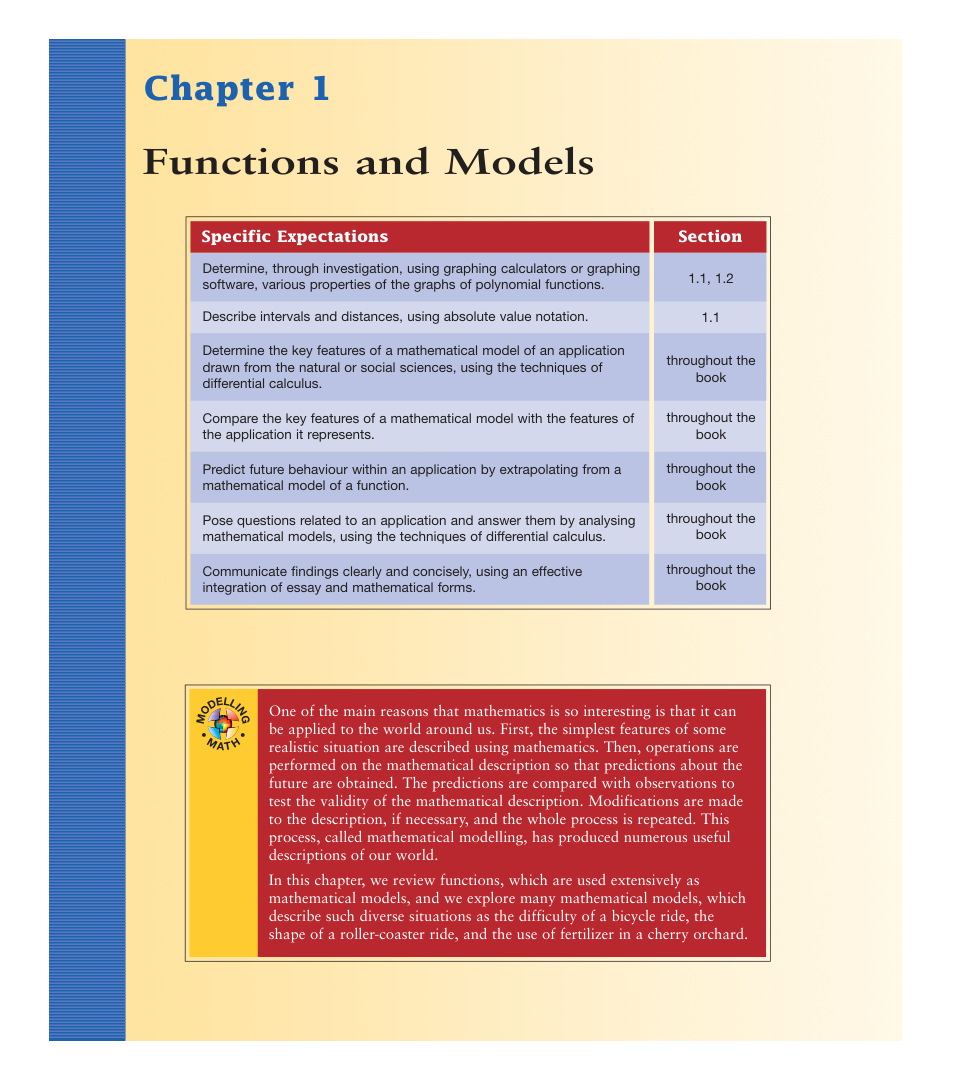

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename="page_images/page_2.png"
    )
)


In [ ]:
{
  "Quadratic functions and graphing parabolas": [
    "page_images/page_12.png",
    "page_images/page_13.png"
  ],
  "Linear equations, slope, and intercepts": [
    "page_images/page_8.png"
  ]
}

{'Quadratic functions and graphing parabolas': ['page_images/page_12.png',
  'page_images/page_13.png'],
 'Linear equations, slope, and intercepts': ['page_images/page_8.png']}

In [ ]:
page_texts = []

pdf = fitz.open(
    "grade12math.pdf"
)

for page_index in range(
    len(pdf)
):

    page = pdf[
        page_index
    ]

    text = page.get_text()

    page_texts.append(
        {
            "page": page_index + 1,
            "text": text
        }
    )

print(
    "Indexed pages:",
    len(page_texts)
)

Indexed pages: 667


In [ ]:
import json

def load_roadmap():

    with open(
        "course_roadmap.json",
        "r"
    ) as f:

        return json.load(f)


roadmap = load_roadmap()

print(
    "Concepts:",
    len(roadmap)
)

print(
    roadmap[:3]
)

Concepts: 27
[{'chapter': 'Functions and Models', 'concept': 'Review of function notation and evaluating functions'}, {'chapter': 'Functions and Models', 'concept': 'Interpreting graphs, domain, and range'}, {'chapter': 'Functions and Models', 'concept': 'Linear equations, slope, and intercepts'}]


In [ ]:
def score_page_for_concept(
    concept,
    page_text
):

    concept_words = concept.lower().replace(
        "(",
        " "
    ).replace(
        ")",
        " "
    ).replace(
        ",",
        " "
    ).split()

    page_lower = page_text.lower()

    score = 0

    for word in concept_words:

        if len(word) > 3 and word in page_lower:
            score += 1

    return score

In [ ]:
### build visual index
def build_visual_index(
    roadmap,
    page_texts,
    top_k=3
):

    visual_index = {}

    for item in roadmap:

        concept = item[
            "concept"
        ]

        scored_pages = []

        for page_item in page_texts:

            score = score_page_for_concept(
                concept,
                page_item["text"]
            )

            if score > 0:

                scored_pages.append(
                    {
                        "page": page_item["page"],
                        "score": score
                    }
                )

        scored_pages = sorted(
            scored_pages,
            key=lambda x: x["score"],
            reverse=True
        )

        top_pages = scored_pages[
            :top_k
        ]

        image_paths = []

        for p in top_pages:

            image_path = os.path.join(
                PAGE_IMAGE_DIR,
                f"page_{p['page']}.png"
            )

            if os.path.exists(
                image_path
            ):

                image_paths.append(
                    image_path
                )

        visual_index[
            concept
        ] = image_paths

    return visual_index

In [ ]:
visual_index = build_visual_index(
    roadmap,
    page_texts,
    top_k=3
)

print(
    list(
        visual_index.items()
    )[:3]
)

[('Review of function notation and evaluating functions', ['page_images/page_2.png', 'page_images/page_4.png', 'page_images/page_6.png']), ('Interpreting graphs, domain, and range', ['page_images/page_4.png', 'page_images/page_26.png']), ('Linear equations, slope, and intercepts', ['page_images/page_28.png'])]


In [ ]:
with open(
    "visual_index.json",
    "w"
) as f:

    json.dump(
        visual_index,
        f,
        indent=2
    )

print(
    "visual_index.json saved"
)

visual_index.json saved


In [ ]:
with open(
    "visual_index.json"
) as f:

    test_visual_index = json.load(f)

print(
    list(
        test_visual_index.keys()
    )[:5]
)

['Review of function notation and evaluating functions', 'Interpreting graphs, domain, and range', 'Linear equations, slope, and intercepts', 'Equations of lines from points and slopes', 'Quadratic functions and graphing parabolas']


In [ ]:
### create question with image cache
IMAGE_QUESTION_CACHE_FILE = "image_question_cache.json"


def load_image_question_cache():

    if not os.path.exists(
        IMAGE_QUESTION_CACHE_FILE
    ):

        return {}

    try:

        with open(
            IMAGE_QUESTION_CACHE_FILE,
            "r"
        ) as f:

            return json.load(f)

    except:

        return {}


def save_image_question_cache(
    cache
):

    with open(
        IMAGE_QUESTION_CACHE_FILE,
        "w"
    ) as f:

        json.dump(
            cache,
            f,
            indent=2
        )


image_question_cache = load_image_question_cache()

print(
    "Cached image questions:",
    len(image_question_cache)
)

Cached image questions: 0


In [ ]:
def get_image_question(
    concept
):

    if concept in image_question_cache:

        print(
            "IMAGE QUESTION CACHE HIT"
        )

        return image_question_cache[
            concept
        ]

    print(
        "GENERATING IMAGE QUESTION..."
    )

    prompt = f"""
You are a Grade 12 math tutor.

Create one graph-based or image-based question for this concept:

{concept}

The student will look at a textbook graph or page image shown on screen.

Return JSON only.

Format:

{{
  "question": "...",
  "answer_key": "...",
  "skills_tested": ["..."]
}}

Requirements:
1. The question must require interpreting a graph, curve, diagram, or visual representation.
2. Do not make it only multiple choice.
3. Include a clear answer key.
4. Keep it appropriate for Grade 12 math.
5. Return valid JSON only.
"""

    result = llm.invoke(
        prompt
    ).content

    result_json = clean_json(
        result
    )

    image_question_cache[
        concept
    ] = result_json

    save_image_question_cache(
        image_question_cache
    )

    return result_json

In [ ]:
current = resume_learning()

concept = current[
    "concept"
]

image_question = get_image_question(
    concept
)

print(
    image_question
)

GENERATING IMAGE QUESTION...
{'question': 'A graph on the textbook page shows a straight line passing through the points A(-2, 5) and B(4, -1). Using the graph, determine the equation of the line in slope-intercept form.', 'answer_key': 'From the graph, the two points are A(-2, 5) and B(4, -1).\nSlope: m = (-1 - 5) / (4 - (-2)) = -6 / 6 = -1.\nUse y = mx + b.\nSubstitute point A(-2, 5):\n5 = -1(-2) + b\n5 = 2 + b\nb = 3.\nEquation of the line: y = -x + 3.', 'skills_tested': ['Finding slope from two points on a graph', 'Determining the y-intercept', 'Writing equations of lines in slope-intercept form', 'Interpreting coordinate graphs']}


In [ ]:
%%writefile app.py

import streamlit as st
import json
import os
from openai import OpenAI

# -----------------------------
# Config
# -----------------------------

PROFILE_FILE = "student_profile.json"
ROADMAP_FILE = "course_roadmap.json"
LESSON_CACHE_FILE = "lesson_cache.json"
QUIZ_CACHE_FILE = "quiz_cache.json"
IMAGE_QUESTION_CACHE_FILE = "image_question_cache.json"
VISUAL_INDEX_FILE = "visual_index.json"

AZURE_ENDPOINT = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
AZURE_MODEL = "gpt-5.3-chat"


# -----------------------------
# Azure LLM
# -----------------------------

def call_llm(prompt):

    api_key = os.environ.get(
        "AZURE_OPENAI_API_KEY"
    )

    if not api_key:

        return "AZURE_OPENAI_API_KEY is not set."

    client = OpenAI(
        api_key=api_key,
        base_url=AZURE_ENDPOINT
    )

    response = client.chat.completions.create(
        model=AZURE_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content


# -----------------------------
# JSON Helpers
# -----------------------------

def load_json(path, default):

    if not os.path.exists(path):

        return default

    try:

        with open(path, "r") as f:
            return json.load(f)

    except:

        return default


def save_json(path, data):

    with open(path, "w") as f:
        json.dump(data, f, indent=2)


def clean_json(text):

    text = text.strip()
    text = text.replace("```json", "")
    text = text.replace("```", "")
    text = text.strip()

    return json.loads(text)


# -----------------------------
# Load Data
# -----------------------------

profile = load_json(
    PROFILE_FILE,
    {
        "student_name": "Tom",
        "current_index": 0,
        "completed": [],
        "weak": [],
        "history": []
    }
)

roadmap = load_json(
    ROADMAP_FILE,
    []
)

lesson_cache = load_json(
    LESSON_CACHE_FILE,
    {}
)

quiz_cache = load_json(
    QUIZ_CACHE_FILE,
    {}
)

image_question_cache = load_json(
    IMAGE_QUESTION_CACHE_FILE,
    {}
)

visual_index = load_json(
    VISUAL_INDEX_FILE,
    {}
)


# -----------------------------
# Tutor Functions
# -----------------------------

def get_current_concept():

    if not roadmap:
        return None

    idx = profile.get(
        "current_index",
        0
    )

    if idx >= len(roadmap):
        return None

    return roadmap[idx]


def get_lesson(concept):

    if concept in lesson_cache:
        return lesson_cache[concept]

    prompt = f"""
You are a Grade 12 math tutor.

Teach this concept:

{concept}

Include:
1. Simple explanation
2. Real-world example
3. Common mistakes
4. One practice question

Use student-friendly language.
"""

    lesson = call_llm(prompt)

    lesson_cache[concept] = lesson

    save_json(
        LESSON_CACHE_FILE,
        lesson_cache
    )

    return lesson


def get_quiz(concept):

    if concept in quiz_cache:
        return quiz_cache[concept]

    prompt = f"""
Create a Grade 12 Math quiz for:

{concept}

Include:
1. Two multiple choice questions
2. One true/false question
3. One application question
4. Answer key
"""

    quiz = call_llm(prompt)

    quiz_cache[concept] = quiz

    save_json(
        QUIZ_CACHE_FILE,
        quiz_cache
    )

    return quiz


def get_image_question(concept):

    if concept in image_question_cache:
        return image_question_cache[concept]

    prompt = f"""
You are a Grade 12 math tutor.

Create one graph-based question for:

{concept}

The student will look at a textbook page image displayed on screen.

Return JSON only.

Format:
{{
  "question": "...",
  "answer_key": "...",
  "skills_tested": ["..."]
}}

Requirements:
1. It must require interpreting a graph, curve, diagram, or visual representation.
2. It must not be only multiple choice.
3. Include a clear answer key.
"""

    result = call_llm(prompt)

    try:
        result_json = clean_json(result)

    except:
        result_json = {
            "question": result,
            "answer_key": "",
            "skills_tested": []
        }

    image_question_cache[concept] = result_json

    save_json(
        IMAGE_QUESTION_CACHE_FILE,
        image_question_cache
    )

    return result_json


def evaluate_answer(concept, quiz, image_question, student_answer):

    prompt = f"""
You are a Grade 12 math teacher.

Evaluate the student's answer.

Concept:
{concept}

Text Quiz:
{quiz}

Image Question:
{image_question}

Student Answer:
{student_answer}

Return JSON only.

Format:
{{
  "mastery_score": 85,
  "feedback": "...",
  "next_action": "mastered/practice/remediation"
}}
"""

    result = call_llm(prompt)

    try:
        return clean_json(result)

    except:
        return {
            "mastery_score": 0,
            "feedback": result,
            "next_action": "practice"
        }


def complete_lesson(concept, score):

    profile["history"].append(
        {
            "concept": concept,
            "score": score
        }
    )

    if score >= 85:

        if concept not in profile["completed"]:
            profile["completed"].append(concept)

        profile["current_index"] += 1

    else:

        if concept not in profile["weak"]:
            profile["weak"].append(concept)

    save_json(
        PROFILE_FILE,
        profile
    )


# -----------------------------
# Streamlit UI
# -----------------------------

st.set_page_config(
    page_title="Grade 12 AI Tutor",
    layout="wide"
)

st.title("📚 Grade 12 AI Tutor")

st.write(
    f"Student: {profile.get('student_name', 'Tom')}"
)

if not roadmap:

    st.error(
        "course_roadmap.json is missing or empty."
    )

    st.stop()


current = get_current_concept()

if current is None:

    st.success(
        "Course completed!"
    )

    st.stop()


concept = current["concept"]
chapter = current["chapter"]

st.subheader("Current Lesson")

st.info(
    f"{chapter} — {concept}"
)

progress = profile.get(
    "current_index",
    0
) / max(len(roadmap), 1)

st.progress(progress)

st.write(
    f"Progress: {profile.get('current_index', 0)} / {len(roadmap)} concepts"
)

col1, col2 = st.columns(2)

with col1:

    st.subheader("Lesson")

    if st.button("Start Lesson"):

        lesson = get_lesson(concept)

        st.write(lesson)

with col2:

    st.subheader("Text Quiz")

    if st.button("Take Text Quiz"):

        quiz = get_quiz(concept)

        st.write(quiz)


st.divider()

st.subheader("Visual / Graph Question")

images = visual_index.get(
    concept,
    []
)

if images:

    st.write("Related textbook image:")

    for image_path in images[:2]:

        if os.path.exists(image_path):

            st.image(
                image_path,
                caption=image_path,
                use_container_width=True
            )

else:

    st.warning(
        "No related image found yet for this concept."
    )


if st.button("Generate Graph Question"):

    image_question = get_image_question(concept)

    st.write(
        image_question["question"]
    )

    with st.expander("Answer Key"):

        st.write(
            image_question.get(
                "answer_key",
                ""
            )
        )


st.divider()

st.subheader("Submit Your Answer")

student_answer = st.text_area(
    "Type your answer here",
    height=180
)

if st.button("Evaluate My Answer"):

    quiz = get_quiz(concept)

    image_question = get_image_question(concept)

    evaluation = evaluate_answer(
        concept,
        quiz,
        image_question,
        student_answer
    )

    score = evaluation.get(
        "mastery_score",
        0
    )

    st.metric(
        "Mastery Score",
        score
    )

    st.write(
        evaluation.get(
            "feedback",
            ""
        )
    )

    if score >= 85:

        st.success(
            "Concept mastered. Moving to next concept."
        )

        complete_lesson(
            concept,
            score
        )

    elif score >= 60:

        st.info(
            "Good progress. More practice recommended."
        )

        complete_lesson(
            concept,
            score
        )

    else:

        st.warning(
            "Remediation recommended. Concept added to weak list."
        )

        complete_lesson(
            concept,
            score
        )


st.divider()

st.subheader("Learning History")

st.write(
    profile.get(
        "history",
        []
    )
)

st.subheader("Weak Concepts")

st.write(
    profile.get(
        "weak",
        []
    )
)
st.divider()

st.subheader("💬 Chat With Tutor")

student_question = st.text_input(
    "Ask a question about the current lesson"
)

if st.button("Ask Tutor"):

    prompt = f"""
You are a patient Grade 12 Mathematics Tutor.

Current Concept:

{concept}

Student Question:

{student_question}

Explain step-by-step.

Use examples.

Avoid advanced terminology.
"""

    tutor_answer = call_llm(
        prompt
    )

    st.session_state.chat_history.append(
        {
            "question":
                student_question,

            "answer":
                tutor_answer
        }
    )

Overwriting app.py


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive

MyDrive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

os.makedirs(
    PROJECT_DIR,
    exist_ok=True
)

print(PROJECT_DIR)

/content/drive/MyDrive/AI_Tutor_Project


In [ ]:
import shutil
import os

PROJECT_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

files_to_backup = [
    "app.py",
    "course_roadmap.json",
    "student_profile.json",
    "lesson_cache.json",
    "quiz_cache.json",
    "image_question_cache.json",
    "visual_index.json",
    "grade12math.pdf"
]

for file in files_to_backup:

    if os.path.exists(file):

        shutil.copy2(
            file,
            os.path.join(
                PROJECT_DIR,
                file
            )
        )

        print(
            "Saved:",
            file
        )

Saved: app.py
Saved: course_roadmap.json
Saved: student_profile.json
Saved: lesson_cache.json
Saved: quiz_cache.json
Saved: image_question_cache.json
Saved: visual_index.json
Saved: grade12math.pdf


In [ ]:
import shutil
import os

src = "page_images"

dst = os.path.join(
    PROJECT_DIR,
    "page_images"
)

if os.path.exists(src):

    if os.path.exists(dst):

        shutil.rmtree(dst)

    shutil.copytree(
        src,
        dst
    )

    print(
        "page_images saved"
    )

page_images saved


In [ ]:
!ls /content/drive/MyDrive/AI_Tutor_Project

app.py		     image_question_cache.json	quiz_cache.json
course_roadmap.json  lesson_cache.json		student_profile.json
grade12math.pdf      page_images		visual_index.json


In [ ]:
import streamlit as st
import json
import os
from openai import OpenAI


# ============================================================
# Config
# ============================================================

# If you run in Google Colab and saved project to Google Drive,
# keep this path.
# If you run locally, change BASE_DIR = "."
BASE_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

if not os.path.exists(BASE_DIR):
    BASE_DIR = "."

PROFILE_FILE = os.path.join(BASE_DIR, "student_profile.json")
ROADMAP_FILE = os.path.join(BASE_DIR, "course_roadmap.json")
LESSON_CACHE_FILE = os.path.join(BASE_DIR, "lesson_cache.json")
QUIZ_CACHE_FILE = os.path.join(BASE_DIR, "quiz_cache.json")
IMAGE_QUESTION_CACHE_FILE = os.path.join(BASE_DIR, "image_question_cache.json")
VISUAL_INDEX_FILE = os.path.join(BASE_DIR, "visual_index.json")

AZURE_ENDPOINT = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
AZURE_MODEL = "gpt-5.3-chat"


# ============================================================
# Azure LLM
# ============================================================

def call_llm(prompt):
    api_key = os.environ.get("AZURE_OPENAI_API_KEY")

    if not api_key:
        return "AZURE_OPENAI_API_KEY is not set. Please set it in your notebook or terminal before running the app."

    client = OpenAI(
        api_key=api_key,
        base_url=AZURE_ENDPOINT
    )

    response = client.chat.completions.create(
        model=AZURE_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content


# ============================================================
# JSON Helpers
# ============================================================

def load_json(path, default):
    if not os.path.exists(path):
        return default

    try:
        with open(path, "r") as f:
            return json.load(f)

    except Exception:
        return default


def save_json(path, data):
    folder = os.path.dirname(path)

    if folder and not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)

    with open(path, "w") as f:
        json.dump(data, f, indent=2)


def clean_json(text):
    text = text.strip()
    text = text.replace("```json", "")
    text = text.replace("```", "")
    text = text.strip()

    return json.loads(text)


# ============================================================
# Load Data
# ============================================================

default_profile = {
    "student_name": "Tom",
    "current_index": 0,
    "completed": [],
    "weak": [],
    "history": []
}

profile = load_json(PROFILE_FILE, default_profile)
roadmap = load_json(ROADMAP_FILE, [])
lesson_cache = load_json(LESSON_CACHE_FILE, {})
quiz_cache = load_json(QUIZ_CACHE_FILE, {})
image_question_cache = load_json(IMAGE_QUESTION_CACHE_FILE, {})
visual_index = load_json(VISUAL_INDEX_FILE, {})


# ============================================================
# Tutor Functions
# ============================================================

def get_current_concept():
    if not roadmap:
        return None

    idx = profile.get("current_index", 0)

    if idx >= len(roadmap):
        return None

    return roadmap[idx]


def get_lesson(concept):
    if concept in lesson_cache:
        return lesson_cache[concept]

    prompt = f"""
You are a friendly Grade 12 math tutor.

Teach this concept:

{concept}

Include:
1. Simple explanation
2. Real-world example
3. Visual analogy if useful
4. Common mistakes
5. One practice question

Use student-friendly language.
Break the explanation into clear steps.
"""

    lesson = call_llm(prompt)

    lesson_cache[concept] = lesson
    save_json(LESSON_CACHE_FILE, lesson_cache)

    return lesson


def get_quiz(concept):
    if concept in quiz_cache:
        return quiz_cache[concept]

    prompt = f"""
Create a Grade 12 math quiz for this concept:

{concept}

Include:
1. Two multiple choice questions
2. One true/false question
3. One application question
4. One short explanation question
5. Answer key

Make the quiz clear and suitable for a student learning this topic for the first time.
"""

    quiz = call_llm(prompt)

    quiz_cache[concept] = quiz
    save_json(QUIZ_CACHE_FILE, quiz_cache)

    return quiz


def get_image_question(concept):
    if concept in image_question_cache:
        return image_question_cache[concept]

    prompt = f"""
You are a Grade 12 mathematics teacher.

Concept:

{concept}

Assume the student is looking at a textbook graph, curve, diagram, or page image related to this concept.

Create one visual / graph-based assessment.

Return JSON only.

Format:
{{
  "question": "...",
  "answer_key": "...",
  "skills_tested": ["..."]
}}

Requirements:
1. The question must require interpreting a graph, curve, diagram, or visual representation.
2. It must not be only multiple choice.
3. Include a clear answer key.
4. Use Grade 12 appropriate language.
5. Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        result_json = clean_json(result)

    except Exception:
        result_json = {
            "question": result,
            "answer_key": "",
            "skills_tested": []
        }

    image_question_cache[concept] = result_json
    save_json(IMAGE_QUESTION_CACHE_FILE, image_question_cache)

    return result_json


def evaluate_answer(concept, quiz, image_question, student_answer):
    prompt = f"""
You are a Grade 12 mathematics teacher.

Evaluate the student's answer carefully.

Concept:
{concept}

Text Quiz:
{quiz}

Visual / Graph Question:
{image_question}

Student Answer:
{student_answer}

Return JSON only.

Format:
{{
  "mastery_score": 85,
  "feedback": "Detailed feedback for the student.",
  "strengths": ["..."],
  "weaknesses": ["..."],
  "recommended_practice": ["..."],
  "next_action": "mastered/practice/remediation"
}}

Scoring guide:
- 85 to 100: mastered
- 60 to 84: practice
- below 60: remediation

Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        return clean_json(result)

    except Exception:
        return {
            "mastery_score": 0,
            "feedback": result,
            "strengths": [],
            "weaknesses": [],
            "recommended_practice": [],
            "next_action": "practice"
        }


def complete_lesson(concept, score):
    profile["history"].append(
        {
            "concept": concept,
            "score": score
        }
    )

    if score >= 85:
        if concept not in profile["completed"]:
            profile["completed"].append(concept)

        profile["current_index"] = profile.get("current_index", 0) + 1

    else:
        if concept not in profile["weak"]:
            profile["weak"].append(concept)

    save_json(PROFILE_FILE, profile)


# ============================================================
# Streamlit Session State
# ============================================================

st.set_page_config(
    page_title="Grade 12 AI Tutor",
    layout="wide"
)

if "lesson" not in st.session_state:
    st.session_state.lesson = None

if "quiz" not in st.session_state:
    st.session_state.quiz = None

if "image_question" not in st.session_state:
    st.session_state.image_question = None

if "evaluation" not in st.session_state:
    st.session_state.evaluation = None

if "chat_history" not in st.session_state:
    st.session_state.chat_history = []


# ============================================================
# Streamlit UI
# ============================================================

st.title("📚 Grade 12 AI Tutor")

st.write(f"Student: {profile.get('student_name', 'Tom')}")

if not roadmap:
    st.error("course_roadmap.json is missing or empty.")
    st.stop()

current = get_current_concept()

if current is None:
    st.success("Course completed!")
    st.stop()

concept = current["concept"]
chapter = current["chapter"]

st.subheader("Current Lesson")
st.info(f"{chapter} — {concept}")

progress = profile.get("current_index", 0) / max(len(roadmap), 1)
st.progress(progress)

st.write(
    f"Progress: {profile.get('current_index', 0)} / {len(roadmap)} concepts"
)

st.write(
    f"Completed: {len(profile.get('completed', []))} | Weak: {len(profile.get('weak', []))}"
)


# ============================================================
# Lesson and Quiz Section
# ============================================================

col1, col2 = st.columns(2)

with col1:
    st.subheader("Lesson")

    if st.button("Start Lesson"):
        st.session_state.lesson = get_lesson(concept)

    if st.session_state.lesson:
        st.write(st.session_state.lesson)

with col2:
    st.subheader("Text Quiz")

    if st.button("Take Text Quiz"):
        st.session_state.quiz = get_quiz(concept)

    if st.session_state.quiz:
        st.write(st.session_state.quiz)


# ============================================================
# Visual / Graph Question
# ============================================================

st.divider()
st.subheader("Visual / Graph Question")

images = visual_index.get(concept, [])

if images:
    st.write("Related textbook image:")

    for image_path in images[:2]:
        full_path = image_path

        if not os.path.isabs(image_path):
            full_path = os.path.join(BASE_DIR, image_path)

        if os.path.exists(full_path):
            st.image(
                full_path,
                caption=image_path,
                use_container_width=True
            )
else:
    st.warning("No related image found yet for this concept.")

if st.button("Generate Graph Question"):
    st.session_state.image_question = get_image_question(concept)

if st.session_state.image_question:
    st.write(st.session_state.image_question.get("question", ""))

    with st.expander("Answer Key"):
        st.write(st.session_state.image_question.get("answer_key", ""))

    with st.expander("Skills Tested"):
        st.write(st.session_state.image_question.get("skills_tested", []))


# ============================================================
# Student Answer and Evaluation
# ============================================================

st.divider()
st.subheader("Submit Your Answer")

student_answer = st.text_area(
    "Type your answer here",
    height=180
)

if st.button("Evaluate My Answer"):
    quiz = st.session_state.quiz

    if not quiz:
        quiz = get_quiz(concept)
        st.session_state.quiz = quiz

    image_question = st.session_state.image_question

    if not image_question:
        image_question = get_image_question(concept)
        st.session_state.image_question = image_question

    evaluation = evaluate_answer(
        concept,
        quiz,
        image_question,
        student_answer
    )

    st.session_state.evaluation = evaluation

    score = evaluation.get("mastery_score", 0)

    st.metric("Mastery Score", score)

    st.write(evaluation.get("feedback", ""))

    if evaluation.get("strengths"):
        st.subheader("Strengths")
        st.write(evaluation.get("strengths", []))

    if evaluation.get("weaknesses"):
        st.subheader("Weaknesses")
        st.write(evaluation.get("weaknesses", []))

    if evaluation.get("recommended_practice"):
        st.subheader("Recommended Practice")
        st.write(evaluation.get("recommended_practice", []))

    if score >= 85:
        st.success("Concept mastered. Moving to next concept.")
        complete_lesson(concept, score)

    elif score >= 60:
        st.info("Good progress. More practice recommended.")
        complete_lesson(concept, score)

    else:
        st.warning("Remediation recommended. Concept added to weak list.")
        complete_lesson(concept, score)


# ============================================================
# Chat With Tutor
# ============================================================

st.divider()
st.subheader("💬 Chat With Tutor")

student_question = st.text_input(
    "Ask a question about the current lesson"
)

if st.button("Ask Tutor"):
    if student_question.strip():
        prompt = f"""
You are a patient Grade 12 mathematics tutor.

Current Concept:
{concept}

Student Question:
{student_question}

Answer simply and step-by-step.
Use examples when helpful.
Avoid overly advanced terminology.
"""

        tutor_answer = call_llm(prompt)

        st.session_state.chat_history.append(
            {
                "question": student_question,
                "answer": tutor_answer
            }
        )

if st.session_state.chat_history:
    st.subheader("Chat History")

    for item in reversed(st.session_state.chat_history):
        st.markdown(f"**Student:** {item['question']}")
        st.markdown(f"**Tutor:** {item['answer']}")
        st.divider()


# ============================================================
# Learning History
# ============================================================

st.divider()
st.subheader("Learning History")

st.write(profile.get("history", []))

st.subheader("Weak Concepts")

st.write(profile.get("weak", []))

st.subheader("Completed Concepts")

st.write(profile.get("completed", []))

2026-07-24 16:47:48.868 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:47:48.869 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:47:48.871 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-07-24 16:47:48.873 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:47:48.874 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:47:48.875 WARNING streamlit.runtime.scriptrunner_utils.script_run_c

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 22.5 MB/s eta 0:00:00


In [ ]:
import streamlit as st

print("Streamlit OK")

Streamlit OK


In [ ]:
%%writefile app.py

Overwriting app.py


In [ ]:
!pip install -q \
streamlit \
openai \
pymupdf

In [ ]:
!wc -l app.py

0 app.py


In [ ]:
!find /content -name "app.py" -type f

/content/drive/MyDrive/AI_Tutor_Project/app.py
/content/app.py


In [ ]:
!cp \
"/content/drive/MyDrive/AI_Tutor_Project/app.py" \
"/content/app.py"

In [ ]:
!find /content -name "app.py" -type f

/content/drive/MyDrive/AI_Tutor_Project/app.py
/content/app.py


In [ ]:
!wc -l "/content/drive/MyDrive/AI_Tutor_Project/app.py"

0 /content/drive/MyDrive/AI_Tutor_Project/app.py


In [ ]:
import streamlit as st
import json
import os
from openai import OpenAI


# ============================================================
# Config
# ============================================================

# If you run in Google Colab and saved project to Google Drive,
# keep this path.
# If you run locally, change BASE_DIR = "."
BASE_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

if not os.path.exists(BASE_DIR):
    BASE_DIR = "."

PROFILE_FILE = os.path.join(BASE_DIR, "student_profile.json")
ROADMAP_FILE = os.path.join(BASE_DIR, "course_roadmap.json")
LESSON_CACHE_FILE = os.path.join(BASE_DIR, "lesson_cache.json")
QUIZ_CACHE_FILE = os.path.join(BASE_DIR, "quiz_cache.json")
IMAGE_QUESTION_CACHE_FILE = os.path.join(BASE_DIR, "image_question_cache.json")
VISUAL_INDEX_FILE = os.path.join(BASE_DIR, "visual_index.json")

AZURE_ENDPOINT = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
AZURE_MODEL = "gpt-5.3-chat"


# ============================================================
# Azure LLM
# ============================================================

def call_llm(prompt):
    api_key = os.environ.get("AZURE_OPENAI_API_KEY")

    if not api_key:
        return "AZURE_OPENAI_API_KEY is not set. Please set it in your notebook or terminal before running the app."

    client = OpenAI(
        api_key=api_key,
        base_url=AZURE_ENDPOINT
    )

    response = client.chat.completions.create(
        model=AZURE_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content


# ============================================================
# JSON Helpers
# ============================================================

def load_json(path, default):
    if not os.path.exists(path):
        return default

    try:
        with open(path, "r") as f:
            return json.load(f)

    except Exception:
        return default


def save_json(path, data):
    folder = os.path.dirname(path)

    if folder and not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)

    with open(path, "w") as f:
        json.dump(data, f, indent=2)


def clean_json(text):
    text = text.strip()
    text = text.replace("```json", "")
    text = text.replace("```", "")
    text = text.strip()

    return json.loads(text)


# ============================================================
# Load Data
# ============================================================

default_profile = {
    "student_name": "Tom",
    "current_index": 0,
    "completed": [],
    "weak": [],
    "history": []
}

profile = load_json(PROFILE_FILE, default_profile)
roadmap = load_json(ROADMAP_FILE, [])
lesson_cache = load_json(LESSON_CACHE_FILE, {})
quiz_cache = load_json(QUIZ_CACHE_FILE, {})
image_question_cache = load_json(IMAGE_QUESTION_CACHE_FILE, {})
visual_index = load_json(VISUAL_INDEX_FILE, {})


# ============================================================
# Tutor Functions
# ============================================================

def get_current_concept():
    if not roadmap:
        return None

    idx = profile.get("current_index", 0)

    if idx >= len(roadmap):
        return None

    return roadmap[idx]


def get_lesson(concept):
    if concept in lesson_cache:
        return lesson_cache[concept]

    prompt = f"""
You are a friendly Grade 12 math tutor.

Teach this concept:

{concept}

Include:
1. Simple explanation
2. Real-world example
3. Visual analogy if useful
4. Common mistakes
5. One practice question

Use student-friendly language.
Break the explanation into clear steps.
"""

    lesson = call_llm(prompt)

    lesson_cache[concept] = lesson
    save_json(LESSON_CACHE_FILE, lesson_cache)

    return lesson


def get_quiz(concept):
    if concept in quiz_cache:
        return quiz_cache[concept]

    prompt = f"""
Create a Grade 12 math quiz for this concept:

{concept}

Include:
1. Two multiple choice questions
2. One true/false question
3. One application question
4. One short explanation question
5. Answer key

Make the quiz clear and suitable for a student learning this topic for the first time.
"""

    quiz = call_llm(prompt)

    quiz_cache[concept] = quiz
    save_json(QUIZ_CACHE_FILE, quiz_cache)

    return quiz


def get_image_question(concept):
    if concept in image_question_cache:
        return image_question_cache[concept]

    prompt = f"""
You are a Grade 12 mathematics teacher.

Concept:

{concept}

Assume the student is looking at a textbook graph, curve, diagram, or page image related to this concept.

Create one visual / graph-based assessment.

Return JSON only.

Format:
{{
  "question": "...",
  "answer_key": "...",
  "skills_tested": ["..."]
}}

Requirements:
1. The question must require interpreting a graph, curve, diagram, or visual representation.
2. It must not be only multiple choice.
3. Include a clear answer key.
4. Use Grade 12 appropriate language.
5. Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        result_json = clean_json(result)

    except Exception:
        result_json = {
            "question": result,
            "answer_key": "",
            "skills_tested": []
        }

    image_question_cache[concept] = result_json
    save_json(IMAGE_QUESTION_CACHE_FILE, image_question_cache)

    return result_json


def evaluate_answer(concept, quiz, image_question, student_answer):
    prompt = f"""
You are a Grade 12 mathematics teacher.

Evaluate the student's answer carefully.

Concept:
{concept}

Text Quiz:
{quiz}

Visual / Graph Question:
{image_question}

Student Answer:
{student_answer}

Return JSON only.

Format:
{{
  "mastery_score": 85,
  "feedback": "Detailed feedback for the student.",
  "strengths": ["..."],
  "weaknesses": ["..."],
  "recommended_practice": ["..."],
  "next_action": "mastered/practice/remediation"
}}

Scoring guide:
- 85 to 100: mastered
- 60 to 84: practice
- below 60: remediation

Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        return clean_json(result)

    except Exception:
        return {
            "mastery_score": 0,
            "feedback": result,
            "strengths": [],
            "weaknesses": [],
            "recommended_practice": [],
            "next_action": "practice"
        }


def complete_lesson(concept, score):
    profile["history"].append(
        {
            "concept": concept,
            "score": score
        }
    )

    if score >= 85:
        if concept not in profile["completed"]:
            profile["completed"].append(concept)

        profile["current_index"] = profile.get("current_index", 0) + 1

    else:
        if concept not in profile["weak"]:
            profile["weak"].append(concept)

    save_json(PROFILE_FILE, profile)


# ============================================================
# Streamlit Session State
# ============================================================

st.set_page_config(
    page_title="Grade 12 AI Tutor",
    layout="wide"
)

if "lesson" not in st.session_state:
    st.session_state.lesson = None

if "quiz" not in st.session_state:
    st.session_state.quiz = None

if "image_question" not in st.session_state:
    st.session_state.image_question = None

if "evaluation" not in st.session_state:
    st.session_state.evaluation = None

if "chat_history" not in st.session_state:
    st.session_state.chat_history = []


# ============================================================
# Streamlit UI
# ============================================================

st.title("📚 Grade 12 AI Tutor")

st.write(f"Student: {profile.get('student_name', 'Tom')}")

if not roadmap:
    st.error("course_roadmap.json is missing or empty.")
    st.stop()

current = get_current_concept()

if current is None:
    st.success("Course completed!")
    st.stop()

concept = current["concept"]
chapter = current["chapter"]

st.subheader("Current Lesson")
st.info(f"{chapter} — {concept}")

progress = profile.get("current_index", 0) / max(len(roadmap), 1)
st.progress(progress)

st.write(
    f"Progress: {profile.get('current_index', 0)} / {len(roadmap)} concepts"
)

st.write(
    f"Completed: {len(profile.get('completed', []))} | Weak: {len(profile.get('weak', []))}"
)


# ============================================================
# Lesson and Quiz Section
# ============================================================

col1, col2 = st.columns(2)

with col1:
    st.subheader("Lesson")

    if st.button("Start Lesson"):
        st.session_state.lesson = get_lesson(concept)

    if st.session_state.lesson:
        st.write(st.session_state.lesson)

with col2:
    st.subheader("Text Quiz")

    if st.button("Take Text Quiz"):
        st.session_state.quiz = get_quiz(concept)

    if st.session_state.quiz:
        st.write(st.session_state.quiz)


# ============================================================
# Visual / Graph Question
# ============================================================

st.divider()
st.subheader("Visual / Graph Question")

images = visual_index.get(concept, [])

if images:
    st.write("Related textbook image:")

    for image_path in images[:2]:
        full_path = image_path

        if not os.path.isabs(image_path):
            full_path = os.path.join(BASE_DIR, image_path)

        if os.path.exists(full_path):
            st.image(
                full_path,
                caption=image_path,
                use_container_width=True
            )
else:
    st.warning("No related image found yet for this concept.")

if st.button("Generate Graph Question"):
    st.session_state.image_question = get_image_question(concept)

if st.session_state.image_question:
    st.write(st.session_state.image_question.get("question", ""))

    with st.expander("Answer Key"):
        st.write(st.session_state.image_question.get("answer_key", ""))

    with st.expander("Skills Tested"):
        st.write(st.session_state.image_question.get("skills_tested", []))


# ============================================================
# Student Answer and Evaluation
# ============================================================

st.divider()
st.subheader("Submit Your Answer")

student_answer = st.text_area(
    "Type your answer here",
    height=180
)

if st.button("Evaluate My Answer"):
    quiz = st.session_state.quiz

    if not quiz:
        quiz = get_quiz(concept)
        st.session_state.quiz = quiz

    image_question = st.session_state.image_question

    if not image_question:
        image_question = get_image_question(concept)
        st.session_state.image_question = image_question

    evaluation = evaluate_answer(
        concept,
        quiz,
        image_question,
        student_answer
    )

    st.session_state.evaluation = evaluation

    score = evaluation.get("mastery_score", 0)

    st.metric("Mastery Score", score)

    st.write(evaluation.get("feedback", ""))

    if evaluation.get("strengths"):
        st.subheader("Strengths")
        st.write(evaluation.get("strengths", []))

    if evaluation.get("weaknesses"):
        st.subheader("Weaknesses")
        st.write(evaluation.get("weaknesses", []))

    if evaluation.get("recommended_practice"):
        st.subheader("Recommended Practice")
        st.write(evaluation.get("recommended_practice", []))

    if score >= 85:
        st.success("Concept mastered. Moving to next concept.")
        complete_lesson(concept, score)

    elif score >= 60:
        st.info("Good progress. More practice recommended.")
        complete_lesson(concept, score)

    else:
        st.warning("Remediation recommended. Concept added to weak list.")
        complete_lesson(concept, score)


# ============================================================
# Chat With Tutor
# ============================================================

st.divider()
st.subheader("💬 Chat With Tutor")

student_question = st.text_input(
    "Ask a question about the current lesson"
)

if st.button("Ask Tutor"):
    if student_question.strip():
        prompt = f"""
You are a patient Grade 12 mathematics tutor.

Current Concept:
{concept}

Student Question:
{student_question}

Answer simply and step-by-step.
Use examples when helpful.
Avoid overly advanced terminology.
"""

        tutor_answer = call_llm(prompt)

        st.session_state.chat_history.append(
            {
                "question": student_question,
                "answer": tutor_answer
            }
        )

if st.session_state.chat_history:
    st.subheader("Chat History")

    for item in reversed(st.session_state.chat_history):
        st.markdown(f"**Student:** {item['question']}")
        st.markdown(f"**Tutor:** {item['answer']}")
        st.divider()


# ============================================================
# Learning History
# ============================================================

st.divider()
st.subheader("Learning History")

st.write(profile.get("history", []))

st.subheader("Weak Concepts")

st.write(profile.get("weak", []))

st.subheader("Completed Concepts")

st.write(profile.get("completed", []))

2026-07-24 16:53:27.427 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:53:27.427 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:53:27.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:53:27.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:53:27.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:53:27.430 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:53:27.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-24 16:53:27.431 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
!find /content -name "app.py" -type f

/content/drive/MyDrive/AI_Tutor_Project/app.py
/content/app.py


In [ ]:
import shutil
import os

PROJECT_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)

files = [
    "course_roadmap.json",
    "student_profile.json",
    "lesson_cache.json",
    "quiz_cache.json",
    "image_question_cache.json",
    "visual_index.json",
    "grade12math.pdf"
]

for file in files:
    if os.path.exists(file):
        shutil.copy2(
            file,
            os.path.join(PROJECT_DIR, file)
        )
        print("Saved:", file)

Saved: course_roadmap.json
Saved: student_profile.json
Saved: lesson_cache.json
Saved: quiz_cache.json
Saved: image_question_cache.json
Saved: visual_index.json
Saved: grade12math.pdf


In [ ]:
if os.path.exists("page_images"):

    dst = os.path.join(
        PROJECT_DIR,
        "page_images"
    )

    if os.path.exists(dst):
        shutil.rmtree(dst)

    shutil.copytree(
        "page_images",
        dst
    )

    print("Saved page_images")

Saved page_images


In [ ]:
# 搜索 notebook 历史输出里的 app.py 内容

!grep -R "st.set_page_config" /content -n 2>/dev/null | head -20

/content/drive/MyDrive/AI-tutor-langgraph.ipynb:1:{"nbformat":4,"nbformat_minor":0,"metadata":{"colab":{"provenance":[],"mount_file_id":"1EIZrq-9imiT99FXGFzP4OLqWO_mfYYkw","authorship_tag":"ABX9TyNG4KtqODgVsDBGEcddThzW"},"kernelspec":{"name":"python3","display_name":"Python 3"},"language_info":{"name":"python"}},"cells":[{"cell_type":"code","execution_count":null,"metadata":{"id":"eDirJDdznU26"},"outputs":[],"source":["!pip install -q \\\n","langgraph \\\n","langchain \\\n","langchain-core \\\n","langchain-google-genai \\\n","pymupdf \\\n","python-dotenv\n","\n","import os\n","import fitz\n","\n","from google.colab import files\n","\n","from langchain_google_genai import ChatGoogleGenerativeAI\n","\n","os.environ[\"GOOGLE_API_KEY\"] = \"YOUR_GOOGLE_API_KEY_HERE\"\n"]},{"cell_type":"code","source":["### Testing\n","llm = ChatGoogleGenerativeAI(\n","    model=\"gemini-2.5-flash\",\n","    temperature=0\n",")\n","\n","response = llm.invoke(\n","    \"Say hello and tell me you are working.

In [ ]:
app_code = """
import streamlit as st

st.title("Test")
"""

with open("app.py", "w") as f:
    f.write(app_code)

In [ ]:
import json

print("Roadmap:",
      len(json.load(open("course_roadmap.json"))))

print("Profile:")
print(json.load(open("student_profile.json")))

print("Lesson Cache Exists:")
print("lesson_cache.json")

print("Quiz Cache Exists:")
print("quiz_cache.json")

Roadmap: 27
Profile:
{'student_name': 'Tom', 'current_index': 3, 'completed': ['Review of function notation and evaluating functions', 'Review of function notation and evaluating functions', 'Linear equations, slope, and intercepts'], 'weak': ['Linear equations, slope, and intercepts'], 'history': [{'concept': 'Review of function notation and evaluating functions', 'score': 88}, {'concept': 'Review of function notation and evaluating functions', 'score': 88}, {'concept': 'Linear equations, slope, and intercepts', 'score': 88}, {'concept': 'Linear equations, slope, and intercepts', 'score': 0}]}
Lesson Cache Exists:
lesson_cache.json
Quiz Cache Exists:
quiz_cache.json


In [ ]:
!cat app.py


import streamlit as st

st.title("Test")


In [ ]:
app_code = """

"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py saved")

In [ ]:
app_code = """
import streamlit as st
import json
import os
from openai import OpenAI


# ============================================================
# Config
# ============================================================

# If you run in Google Colab and saved project to Google Drive,
# keep this path.
# If you run locally, change BASE_DIR = "."
BASE_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

if not os.path.exists(BASE_DIR):
    BASE_DIR = "."

PROFILE_FILE = os.path.join(BASE_DIR, "student_profile.json")
ROADMAP_FILE = os.path.join(BASE_DIR, "course_roadmap.json")
LESSON_CACHE_FILE = os.path.join(BASE_DIR, "lesson_cache.json")
QUIZ_CACHE_FILE = os.path.join(BASE_DIR, "quiz_cache.json")
IMAGE_QUESTION_CACHE_FILE = os.path.join(BASE_DIR, "image_question_cache.json")
VISUAL_INDEX_FILE = os.path.join(BASE_DIR, "visual_index.json")

AZURE_ENDPOINT = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
AZURE_MODEL = "gpt-5.3-chat"


# ============================================================
# Azure LLM
# ============================================================

def call_llm(prompt):
    api_key = os.environ.get("AZURE_OPENAI_API_KEY")

    if not api_key:
        return "AZURE_OPENAI_API_KEY is not set. Please set it in your notebook or terminal before running the app."

    client = OpenAI(
        api_key=api_key,
        base_url=AZURE_ENDPOINT
    )

    response = client.chat.completions.create(
        model=AZURE_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content


# ============================================================
# JSON Helpers
# ============================================================

def load_json(path, default):
    if not os.path.exists(path):
        return default

    try:
        with open(path, "r") as f:
            return json.load(f)

    except Exception:
        return default


def save_json(path, data):
    folder = os.path.dirname(path)

    if folder and not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)

    with open(path, "w") as f:
        json.dump(data, f, indent=2)


def clean_json(text):
    text = text.strip()
    text = text.replace("```json", "")
    text = text.replace("```", "")
    text = text.strip()

    return json.loads(text)


# ============================================================
# Load Data
# ============================================================

default_profile = {
    "student_name": "Tom",
    "current_index": 0,
    "completed": [],
    "weak": [],
    "history": []
}

profile = load_json(PROFILE_FILE, default_profile)
roadmap = load_json(ROADMAP_FILE, [])
lesson_cache = load_json(LESSON_CACHE_FILE, {})
quiz_cache = load_json(QUIZ_CACHE_FILE, {})
image_question_cache = load_json(IMAGE_QUESTION_CACHE_FILE, {})
visual_index = load_json(VISUAL_INDEX_FILE, {})


# ============================================================
# Tutor Functions
# ============================================================

def get_current_concept():
    if not roadmap:
        return None

    idx = profile.get("current_index", 0)

    if idx >= len(roadmap):
        return None

    return roadmap[idx]


def get_lesson(concept):
    if concept in lesson_cache:
        return lesson_cache[concept]

    prompt = f"""
You are a friendly Grade 12 math tutor.

Teach this concept:

{concept}

Include:
1. Simple explanation
2. Real-world example
3. Visual analogy if useful
4. Common mistakes
5. One practice question

Use student-friendly language.
Break the explanation into clear steps.
"""

    lesson = call_llm(prompt)

    lesson_cache[concept] = lesson
    save_json(LESSON_CACHE_FILE, lesson_cache)

    return lesson


def get_quiz(concept):
    if concept in quiz_cache:
        return quiz_cache[concept]

    prompt = f"""
Create a Grade 12 math quiz for this concept:

{concept}

Include:
1. Two multiple choice questions
2. One true/false question
3. One application question
4. One short explanation question
5. Answer key

Make the quiz clear and suitable for a student learning this topic for the first time.
"""

    quiz = call_llm(prompt)

    quiz_cache[concept] = quiz
    save_json(QUIZ_CACHE_FILE, quiz_cache)

    return quiz


def get_image_question(concept):
    if concept in image_question_cache:
        return image_question_cache[concept]

    prompt = f"""
You are a Grade 12 mathematics teacher.

Concept:

{concept}

Assume the student is looking at a textbook graph, curve, diagram, or page image related to this concept.

Create one visual / graph-based assessment.

Return JSON only.

Format:
{{
  "question": "...",
  "answer_key": "...",
  "skills_tested": ["..."]
}}

Requirements:
1. The question must require interpreting a graph, curve, diagram, or visual representation.
2. It must not be only multiple choice.
3. Include a clear answer key.
4. Use Grade 12 appropriate language.
5. Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        result_json = clean_json(result)

    except Exception:
        result_json = {
            "question": result,
            "answer_key": "",
            "skills_tested": []
        }

    image_question_cache[concept] = result_json
    save_json(IMAGE_QUESTION_CACHE_FILE, image_question_cache)

    return result_json


def evaluate_answer(concept, quiz, image_question, student_answer):
    prompt = f"""
You are a Grade 12 mathematics teacher.

Evaluate the student's answer carefully.

Concept:
{concept}

Text Quiz:
{quiz}

Visual / Graph Question:
{image_question}

Student Answer:
{student_answer}

Return JSON only.

Format:
{{
  "mastery_score": 85,
  "feedback": "Detailed feedback for the student.",
  "strengths": ["..."],
  "weaknesses": ["..."],
  "recommended_practice": ["..."],
  "next_action": "mastered/practice/remediation"
}}

Scoring guide:
- 85 to 100: mastered
- 60 to 84: practice
- below 60: remediation

Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        return clean_json(result)

    except Exception:
        return {
            "mastery_score": 0,
            "feedback": result,
            "strengths": [],
            "weaknesses": [],
            "recommended_practice": [],
            "next_action": "practice"
        }


def complete_lesson(concept, score):
    profile["history"].append(
        {
            "concept": concept,
            "score": score
        }
    )

    if score >= 85:
        if concept not in profile["completed"]:
            profile["completed"].append(concept)

        profile["current_index"] = profile.get("current_index", 0) + 1

    else:
        if concept not in profile["weak"]:
            profile["weak"].append(concept)

    save_json(PROFILE_FILE, profile)


# ============================================================
# Streamlit Session State
# ============================================================

st.set_page_config(
    page_title="Grade 12 AI Tutor",
    layout="wide"
)

if "lesson" not in st.session_state:
    st.session_state.lesson = None

if "quiz" not in st.session_state:
    st.session_state.quiz = None

if "image_question" not in st.session_state:
    st.session_state.image_question = None

if "evaluation" not in st.session_state:
    st.session_state.evaluation = None

if "chat_history" not in st.session_state:
    st.session_state.chat_history = []


# ============================================================
# Streamlit UI
# ============================================================

st.title("📚 Grade 12 AI Tutor")

st.write(f"Student: {profile.get('student_name', 'Tom')}")

if not roadmap:
    st.error("course_roadmap.json is missing or empty.")
    st.stop()

current = get_current_concept()

if current is None:
    st.success("Course completed!")
    st.stop()

concept = current["concept"]
chapter = current["chapter"]

st.subheader("Current Lesson")
st.info(f"{chapter} — {concept}")

progress = profile.get("current_index", 0) / max(len(roadmap), 1)
st.progress(progress)

st.write(
    f"Progress: {profile.get('current_index', 0)} / {len(roadmap)} concepts"
)

st.write(
    f"Completed: {len(profile.get('completed', []))} | Weak: {len(profile.get('weak', []))}"
)


# ============================================================
# Lesson and Quiz Section
# ============================================================

col1, col2 = st.columns(2)

with col1:
    st.subheader("Lesson")

    if st.button("Start Lesson"):
        st.session_state.lesson = get_lesson(concept)

    if st.session_state.lesson:
        st.write(st.session_state.lesson)

with col2:
    st.subheader("Text Quiz")

    if st.button("Take Text Quiz"):
        st.session_state.quiz = get_quiz(concept)

    if st.session_state.quiz:
        st.write(st.session_state.quiz)


# ============================================================
# Visual / Graph Question
# ============================================================

st.divider()
st.subheader("Visual / Graph Question")

images = visual_index.get(concept, [])

if images:
    st.write("Related textbook image:")

    for image_path in images[:2]:
        full_path = image_path

        if not os.path.isabs(image_path):
            full_path = os.path.join(BASE_DIR, image_path)

        if os.path.exists(full_path):
            st.image(
                full_path,
                caption=image_path,
                use_container_width=True
            )
else:
    st.warning("No related image found yet for this concept.")

if st.button("Generate Graph Question"):
    st.session_state.image_question = get_image_question(concept)

if st.session_state.image_question:
    st.write(st.session_state.image_question.get("question", ""))

    with st.expander("Answer Key"):
        st.write(st.session_state.image_question.get("answer_key", ""))

    with st.expander("Skills Tested"):
        st.write(st.session_state.image_question.get("skills_tested", []))


# ============================================================
# Student Answer and Evaluation
# ============================================================

st.divider()
st.subheader("Submit Your Answer")

student_answer = st.text_area(
    "Type your answer here",
    height=180
)

if st.button("Evaluate My Answer"):
    quiz = st.session_state.quiz

    if not quiz:
        quiz = get_quiz(concept)
        st.session_state.quiz = quiz

    image_question = st.session_state.image_question

    if not image_question:
        image_question = get_image_question(concept)
        st.session_state.image_question = image_question

    evaluation = evaluate_answer(
        concept,
        quiz,
        image_question,
        student_answer
    )

    st.session_state.evaluation = evaluation

    score = evaluation.get("mastery_score", 0)

    st.metric("Mastery Score", score)

    st.write(evaluation.get("feedback", ""))

    if evaluation.get("strengths"):
        st.subheader("Strengths")
        st.write(evaluation.get("strengths", []))

    if evaluation.get("weaknesses"):
        st.subheader("Weaknesses")
        st.write(evaluation.get("weaknesses", []))

    if evaluation.get("recommended_practice"):
        st.subheader("Recommended Practice")
        st.write(evaluation.get("recommended_practice", []))

    if score >= 85:
        st.success("Concept mastered. Moving to next concept.")
        complete_lesson(concept, score)

    elif score >= 60:
        st.info("Good progress. More practice recommended.")
        complete_lesson(concept, score)

    else:
        st.warning("Remediation recommended. Concept added to weak list.")
        complete_lesson(concept, score)


# ============================================================
# Chat With Tutor
# ============================================================

st.divider()
st.subheader("💬 Chat With Tutor")

student_question = st.text_input(
    "Ask a question about the current lesson"
)

if st.button("Ask Tutor"):
    if student_question.strip():
        prompt = f"""
You are a patient Grade 12 mathematics tutor.

Current Concept:
{concept}

Student Question:
{student_question}

Answer simply and step-by-step.
Use examples when helpful.
Avoid overly advanced terminology.
"""

        tutor_answer = call_llm(prompt)

        st.session_state.chat_history.append(
            {
                "question": student_question,
                "answer": tutor_answer
            }
        )

if st.session_state.chat_history:
    st.subheader("Chat History")

    for item in reversed(st.session_state.chat_history):
        st.markdown(f"**Student:** {item['question']}")
        st.markdown(f"**Tutor:** {item['answer']}")
        st.divider()


# ============================================================
# Learning History
# ============================================================

st.divider()
st.subheader("Learning History")

st.write(profile.get("history", []))

st.subheader("Weak Concepts")

st.write(profile.get("weak", []))

st.subheader("Completed Concepts")

st.write(profile.get("completed", []))
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py saved")

SyntaxError: unterminated string literal (detected at line 241) (433495978.py, line 241)

In [ ]:
!cat logs.txt



2026-07-24 17:08:59.528 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://107.167.183.114:8501



In [ ]:
!streamlit run app.py --server.port 8501 > logs.txt 2>&1 &

In [ ]:
%%writefile app.py
import streamlit as st

st.title("AI Tutor")

st.write("App file created successfully.")

Overwriting app.py


In [ ]:
!wc -l app.py

5 app.py


In [ ]:
!cat app.py

import streamlit as st

st.title("AI Tutor")

st.write("App file created successfully.")


In [ ]:
%%writefile app.py
import streamlit as st
import json
import os
from openai import OpenAI


# ============================================================
# Config
# ============================================================

# If you run in Google Colab and saved project to Google Drive,
# keep this path.
# If you run locally, change BASE_DIR = "."
BASE_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

if not os.path.exists(BASE_DIR):
    BASE_DIR = "."

PROFILE_FILE = os.path.join(BASE_DIR, "student_profile.json")
ROADMAP_FILE = os.path.join(BASE_DIR, "course_roadmap.json")
LESSON_CACHE_FILE = os.path.join(BASE_DIR, "lesson_cache.json")
QUIZ_CACHE_FILE = os.path.join(BASE_DIR, "quiz_cache.json")
IMAGE_QUESTION_CACHE_FILE = os.path.join(BASE_DIR, "image_question_cache.json")
VISUAL_INDEX_FILE = os.path.join(BASE_DIR, "visual_index.json")

AZURE_ENDPOINT  = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
AZURE_MODEL = "gpt-5.3-chat"


# ============================================================
# Azure LLM
# ============================================================

def call_llm(prompt):
    api_key = os.environ.get("AZURE_OPENAI_API_KEY")

    if not api_key:
        return "AZURE_OPENAI_API_KEY is not set. Please set it in your notebook or terminal before running the app."

    client = OpenAI(
        api_key=api_key,
        base_url=AZURE_ENDPOINT
    )

    response = client.chat.completions.create(
        model=AZURE_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content


# ============================================================
# JSON Helpers
# ============================================================

def load_json(path, default):
    if not os.path.exists(path):
        return default

    try:
        with open(path, "r") as f:
            return json.load(f)

    except Exception:
        return default


def save_json(path, data):
    folder = os.path.dirname(path)

    if folder and not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)

    with open(path, "w") as f:
        json.dump(data, f, indent=2)


def clean_json(text):
    text = text.strip()
    text = text.replace("```json", "")
    text = text.replace("```", "")
    text = text.strip()

    return json.loads(text)


# ============================================================
# Load Data
# ============================================================

default_profile = {
    "student_name": "Tom",
    "current_index": 0,
    "completed": [],
    "weak": [],
    "history": []
}

profile = load_json(PROFILE_FILE, default_profile)
roadmap = load_json(ROADMAP_FILE, [])
lesson_cache = load_json(LESSON_CACHE_FILE, {})
quiz_cache = load_json(QUIZ_CACHE_FILE, {})
image_question_cache = load_json(IMAGE_QUESTION_CACHE_FILE, {})
visual_index = load_json(VISUAL_INDEX_FILE, {})


# ============================================================
# Tutor Functions
# ============================================================

def get_current_concept():
    if not roadmap:
        return None

    idx = profile.get("current_index", 0)

    if idx >= len(roadmap):
        return None

    return roadmap[idx]


def get_lesson(concept):
    if concept in lesson_cache:
        return lesson_cache[concept]

    prompt = f"""
You are a friendly Grade 12 math tutor.

Teach this concept:

{concept}

Include:
1. Simple explanation
2. Real-world example
3. Visual analogy if useful
4. Common mistakes
5. One practice question

Use student-friendly language.
Break the explanation into clear steps.
"""

    lesson = call_llm(prompt)

    lesson_cache[concept] = lesson
    save_json(LESSON_CACHE_FILE, lesson_cache)

    return lesson


def get_quiz(concept):
    if concept in quiz_cache:
        return quiz_cache[concept]

    prompt = f"""
Create a Grade 12 math quiz for this concept:

{concept}

Include:
1. Two multiple choice questions
2. One true/false question
3. One application question
4. One short explanation question
5. Answer key

Make the quiz clear and suitable for a student learning this topic for the first time.
"""

    quiz = call_llm(prompt)

    quiz_cache[concept] = quiz
    save_json(QUIZ_CACHE_FILE, quiz_cache)

    return quiz


def get_image_question(concept):
    if concept in image_question_cache:
        return image_question_cache[concept]

    prompt = f"""
You are a Grade 12 mathematics teacher.

Concept:

{concept}

Assume the student is looking at a textbook graph, curve, diagram, or page image related to this concept.

Create one visual / graph-based assessment.

Return JSON only.

Format:
{{
  "question": "...",
  "answer_key": "...",
  "skills_tested": ["..."]
}}

Requirements:
1. The question must require interpreting a graph, curve, diagram, or visual representation.
2. It must not be only multiple choice.
3. Include a clear answer key.
4. Use Grade 12 appropriate language.
5. Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        result_json = clean_json(result)

    except Exception:
        result_json = {
            "question": result,
            "answer_key": "",
            "skills_tested": []
        }

    image_question_cache[concept] = result_json
    save_json(IMAGE_QUESTION_CACHE_FILE, image_question_cache)

    return result_json


def evaluate_answer(concept, quiz, image_question, student_answer):
    prompt = f"""
You are a Grade 12 mathematics teacher.

Evaluate the student's answer carefully.

Concept:
{concept}

Text Quiz:
{quiz}

Visual / Graph Question:
{image_question}

Student Answer:
{student_answer}

Return JSON only.

Format:
{{
  "mastery_score": 85,
  "feedback": "Detailed feedback for the student.",
  "strengths": ["..."],
  "weaknesses": ["..."],
  "recommended_practice": ["..."],
  "next_action": "mastered/practice/remediation"
}}

Scoring guide:
- 85 to 100: mastered
- 60 to 84: practice
- below 60: remediation

Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        return clean_json(result)

    except Exception:
        return {
            "mastery_score": 0,
            "feedback": result,
            "strengths": [],
            "weaknesses": [],
            "recommended_practice": [],
            "next_action": "practice"
        }


def complete_lesson(concept, score):
    profile["history"].append(
        {
            "concept": concept,
            "score": score
        }
    )

    if score >= 85:
        if concept not in profile["completed"]:
            profile["completed"].append(concept)

        profile["current_index"] = profile.get("current_index", 0) + 1

    else:
        if concept not in profile["weak"]:
            profile["weak"].append(concept)

    save_json(PROFILE_FILE, profile)


# ============================================================
# Streamlit Session State
# ============================================================

st.set_page_config(
    page_title="Grade 12 AI Tutor",
    layout="wide"
)

if "lesson" not in st.session_state:
    st.session_state.lesson = None

if "quiz" not in st.session_state:
    st.session_state.quiz = None

if "image_question" not in st.session_state:
    st.session_state.image_question = None

if "evaluation" not in st.session_state:
    st.session_state.evaluation = None

if "chat_history" not in st.session_state:
    st.session_state.chat_history = []


# ============================================================
# Streamlit UI
# ============================================================

st.title("📚 Grade 12 AI Tutor")

st.write(f"Student: {profile.get('student_name', 'Tom')}")

if not roadmap:
    st.error("course_roadmap.json is missing or empty.")
    st.stop()

current = get_current_concept()

if current is None:
    st.success("Course completed!")
    st.stop()

concept = current["concept"]
chapter = current["chapter"]

st.subheader("Current Lesson")
st.info(f"{chapter} — {concept}")

progress = profile.get("current_index", 0) / max(len(roadmap), 1)
st.progress(progress)

st.write(
    f"Progress: {profile.get('current_index', 0)} / {len(roadmap)} concepts"
)

st.write(
    f"Completed: {len(profile.get('completed', []))} | Weak: {len(profile.get('weak', []))}"
)


# ============================================================
# Lesson and Quiz Section
# ============================================================

col1, col2 = st.columns(2)

with col1:
    st.subheader("Lesson")

    if st.button("Start Lesson"):
        st.session_state.lesson = get_lesson(concept)

    if st.session_state.lesson:
        st.write(st.session_state.lesson)

with col2:
    st.subheader("Text Quiz")

    if st.button("Take Text Quiz"):
        st.session_state.quiz = get_quiz(concept)

    if st.session_state.quiz:
        st.write(st.session_state.quiz)


# ============================================================
# Visual / Graph Question
# ============================================================

st.divider()
st.subheader("Visual / Graph Question")

images = visual_index.get(concept, [])

if images:
    st.write("Related textbook image:")

    for image_path in images[:2]:
        full_path = image_path

        if not os.path.isabs(image_path):
            full_path = os.path.join(BASE_DIR, image_path)

        if os.path.exists(full_path):
            st.image(
                full_path,
                caption=image_path,
                use_container_width=True
            )
else:
    st.warning("No related image found yet for this concept.")

if st.button("Generate Graph Question"):
    st.session_state.image_question = get_image_question(concept)

if st.session_state.image_question:
    st.write(st.session_state.image_question.get("question", ""))

    with st.expander("Answer Key"):
        st.write(st.session_state.image_question.get("answer_key", ""))

    with st.expander("Skills Tested"):
        st.write(st.session_state.image_question.get("skills_tested", []))


# ============================================================
# Student Answer and Evaluation
# ============================================================

st.divider()
st.subheader("Submit Your Answer")

student_answer = st.text_area(
    "Type your answer here",
    height=180
)

if st.button("Evaluate My Answer"):
    quiz = st.session_state.quiz

    if not quiz:
        quiz = get_quiz(concept)
        st.session_state.quiz = quiz

    image_question = st.session_state.image_question

    if not image_question:
        image_question = get_image_question(concept)
        st.session_state.image_question = image_question

    evaluation = evaluate_answer(
        concept,
        quiz,
        image_question,
        student_answer
    )

    st.session_state.evaluation = evaluation

    score = evaluation.get("mastery_score", 0)

    st.metric("Mastery Score", score)

    st.write(evaluation.get("feedback", ""))

    if evaluation.get("strengths"):
        st.subheader("Strengths")
        st.write(evaluation.get("strengths", []))

    if evaluation.get("weaknesses"):
        st.subheader("Weaknesses")
        st.write(evaluation.get("weaknesses", []))

    if evaluation.get("recommended_practice"):
        st.subheader("Recommended Practice")
        st.write(evaluation.get("recommended_practice", []))

    if score >= 85:
        st.success("Concept mastered. Moving to next concept.")
        complete_lesson(concept, score)

    elif score >= 60:
        st.info("Good progress. More practice recommended.")
        complete_lesson(concept, score)

    else:
        st.warning("Remediation recommended. Concept added to weak list.")
        complete_lesson(concept, score)


# ============================================================
# Chat With Tutor
# ============================================================

st.divider()
st.subheader("💬 Chat With Tutor")

student_question = st.text_input(
    "Ask a question about the current lesson"
)

if st.button("Ask Tutor"):
    if student_question.strip():
        prompt = f"""
You are a patient Grade 12 mathematics tutor.

Current Concept:
{concept}

Student Question:
{student_question}

Answer simply and step-by-step.
Use examples when helpful.
Avoid overly advanced terminology.
"""

        tutor_answer = call_llm(prompt)

        st.session_state.chat_history.append(
            {
                "question": student_question,
                "answer": tutor_answer
            }
        )

if st.session_state.chat_history:
    st.subheader("Chat History")

    for item in reversed(st.session_state.chat_history):
        st.markdown(f"**Student:** {item['question']}")
        st.markdown(f"**Tutor:** {item['answer']}")
        st.divider()


# ============================================================
# Learning History
# ============================================================

st.divider()
st.subheader("Learning History")

st.write(profile.get("history", []))

st.subheader("Weak Concepts")

st.write(profile.get("weak", []))

st.subheader("Completed Concepts")

st.write(profile.get("completed", []))
with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py saved")

Overwriting app.py


In [ ]:
current = resume_learning()

concept = current["concept"]

print(concept)

lesson = get_lesson(concept)
print(lesson[:500])

quiz = get_quiz(concept)
print(quiz[:500])

Equations of lines from points and slopes
Equations of lines from points and slopes

A line can be described if you know:
- one point on the line
- the slope of the line

The slope tells you how steep the line is.

Step 1: Understand slope

Slope measures how much the line rises or falls.

Formula:
m = rise / run

- Positive slope: line goes upward to the right
- Negative slope: line goes downward to the right
- Zero slope: flat horizontal line

Example:
If a line goes up 3 units while moving right 2 units, the slope is 3/2.

Step 2: Us
Grade 12 Math Quiz: Equations of Lines from Points and Slopes

Name: _______________________
Date: _______________________

Instructions:
Answer all questions. Show your work where needed.

1. Multiple Choice

A line has a slope of 3 and passes through the point (2, 5). Which equation represents the line?

A. y = 3x - 1
B. y = 3x + 5
C. y = 5x - 3
D. y = 3x + 2

2. Multiple Choice

What is the equation of a line with slope -2 that passes through the poi

In [ ]:
current = resume_learning()

concept = current["concept"]

print(concept)

Equations of lines from points and slopes


In [ ]:
lesson = get_lesson(
    concept
)

print(
    lesson[:1000]
)

Equations of lines from points and slopes

A line can be described if you know:
- one point on the line
- the slope of the line

The slope tells you how steep the line is.

Step 1: Understand slope

Slope measures how much the line rises or falls.

Formula:
m = rise / run

- Positive slope: line goes upward to the right
- Negative slope: line goes downward to the right
- Zero slope: flat horizontal line

Example:
If a line goes up 3 units while moving right 2 units, the slope is 3/2.

Step 2: Use the point-slope formula

If you know:
- slope = m
- point = (x₁, y₁)

you can write the equation using:

y − y₁ = m(x − x₁)

This is called point-slope form.

Step 3: Example

Write the equation of a line with:
- slope = 2
- passing through (3, 5)

Use the formula:

y − y₁ = m(x − x₁)

Substitute the values:
y − 5 = 2(x − 3)

That is the equation in point-slope form.

You can also simplify it:

y − 5 = 2x − 6
y = 2x − 1

So the equation is:
y = 2x − 1

Step 4: Real-world example

Imagine ridin

In [ ]:
quiz = get_quiz(
    "Equations of lines from points and slopes"
)

print(quiz[:1000])

Grade 12 Math Quiz: Equations of Lines from Points and Slopes

Name: _______________________
Date: _______________________

Instructions:
Answer all questions. Show your work where needed.

1. Multiple Choice

A line has a slope of 3 and passes through the point (2, 5). Which equation represents the line?

A. y = 3x - 1
B. y = 3x + 5
C. y = 5x - 3
D. y = 3x + 2

2. Multiple Choice

What is the equation of a line with slope -2 that passes through the point (1, 4)?

A. y = -2x + 6
B. y = -2x + 4
C. y = 2x + 6
D. y = -2x - 4

3. True or False

A line with slope 0 is a horizontal line.

True / False

4. Application Question

A hiking trail rises steadily. At one point, the trail is 120 meters above sea level. After moving 3 kilometers forward, the trail is 180 meters above sea level.

a) Find the slope of the trail.

b) Write an equation for the height of the trail using slope-intercept form y = mx + b, where x is the distance traveled in kilometers and y is the height above sea level in m

In [ ]:
%%writefile app.py
import streamlit as st
import json
import os
from openai import OpenAI


# ============================================================
# Config
# ============================================================

BASE_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

if not os.path.exists(BASE_DIR):
    BASE_DIR = "."

PROFILE_FILE = os.path.join(BASE_DIR, "student_profile.json")
ROADMAP_FILE = os.path.join(BASE_DIR, "course_roadmap.json")
LESSON_CACHE_FILE = os.path.join(BASE_DIR, "lesson_cache.json")
QUIZ_CACHE_FILE = os.path.join(BASE_DIR, "quiz_cache.json")
IMAGE_QUESTION_CACHE_FILE = os.path.join(BASE_DIR, "image_question_cache.json")
VISUAL_INDEX_FILE = os.path.join(BASE_DIR, "visual_index.json")

AZURE_ENDPOINT = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
AZURE_MODEL = "gpt-5.3-chat"


# ============================================================
# Azure LLM
# ============================================================

def call_llm(prompt):
    api_key = os.environ.get("AZURE_OPENAI_API_KEY")

    if not api_key:
        return "AZURE_OPENAI_API_KEY is not set. Please set it in your notebook before running the app."

    client = OpenAI(
        api_key=api_key,
        base_url=AZURE_ENDPOINT
    )

    response = client.chat.completions.create(
        model=AZURE_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response.choices[0].message.content


# ============================================================
# JSON Helpers
# ============================================================

def load_json(path, default):
    if not os.path.exists(path):
        return default

    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)

    except Exception:
        return default


def save_json(path, data):
    folder = os.path.dirname(path)

    if folder and not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)

    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def clean_json(text):
    text = text.strip()
    text = text.replace("```json", "")
    text = text.replace("```", "")
    text = text.strip()

    return json.loads(text)


# ============================================================
# Load Data
# ============================================================

default_profile = {
    "student_name": "Tom",
    "current_index": 0,
    "completed": [],
    "weak": [],
    "history": []
}

profile = load_json(PROFILE_FILE, default_profile)
roadmap = load_json(ROADMAP_FILE, [])
lesson_cache = load_json(LESSON_CACHE_FILE, {})
quiz_cache = load_json(QUIZ_CACHE_FILE, {})
image_question_cache = load_json(IMAGE_QUESTION_CACHE_FILE, {})
visual_index = load_json(VISUAL_INDEX_FILE, {})


# ============================================================
# Tutor Functions
# ============================================================

def get_current_concept():
    if not roadmap:
        return None

    idx = profile.get("current_index", 0)

    if idx >= len(roadmap):
        return None

    return roadmap[idx]


def get_lesson(concept):
    if concept in lesson_cache:
        return lesson_cache[concept]

    prompt = f"""
You are a friendly Grade 12 math tutor.

Teach this concept:

{concept}

Include:
1. Simple explanation
2. Real-world example
3. Visual analogy if useful
4. Common mistakes
5. One practice question

Use student-friendly language.
Break the explanation into clear steps.
"""

    lesson = call_llm(prompt)

    lesson_cache[concept] = lesson
    save_json(LESSON_CACHE_FILE, lesson_cache)

    return lesson


def get_quiz(concept):
    if concept in quiz_cache:
        return quiz_cache[concept]

    prompt = f"""
Create a Grade 12 math quiz for this concept:

{concept}

Include:
1. Two multiple choice questions
2. One true/false question
3. One application question
4. One short explanation question
5. Answer key

Make the quiz clear and suitable for a student learning this topic for the first time.
"""

    quiz = call_llm(prompt)

    quiz_cache[concept] = quiz
    save_json(QUIZ_CACHE_FILE, quiz_cache)

    return quiz


def get_image_question(concept):
    if concept in image_question_cache:
        return image_question_cache[concept]

    prompt = f"""
You are a Grade 12 mathematics teacher.

Concept:

{concept}

Assume the student is looking at a textbook graph, curve, diagram, or page image related to this concept.

Create one visual / graph-based assessment.

Return JSON only.

Format:
{{
  "question": "...",
  "answer_key": "...",
  "skills_tested": ["..."]
}}

Requirements:
1. The question must require interpreting a graph, curve, diagram, or visual representation.
2. The question must not be only multiple choice.
3. Include a clear answer key.
4. Use Grade 12 appropriate language.
5. Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        result_json = clean_json(result)

    except Exception:
        result_json = {
            "question": result,
            "answer_key": "",
            "skills_tested": []
        }

    image_question_cache[concept] = result_json
    save_json(IMAGE_QUESTION_CACHE_FILE, image_question_cache)

    return result_json


def evaluate_answer(concept, quiz, image_question, student_answer):
    prompt = f"""
You are a Grade 12 mathematics teacher.

Evaluate the student's answer carefully.

Concept:
{concept}

Text Quiz:
{quiz}

Visual / Graph Question:
{image_question}

Student Answer:
{student_answer}

Return JSON only.

Format:
{{
  "mastery_score": 85,
  "feedback": "Detailed feedback for the student.",
  "strengths": ["..."],
  "weaknesses": ["..."],
  "recommended_practice": ["..."],
  "next_action": "mastered/practice/remediation"
}}

Scoring guide:
- 85 to 100: mastered
- 60 to 84: practice
- below 60: remediation

Do not include markdown.
"""

    result = call_llm(prompt)

    try:
        return clean_json(result)

    except Exception:
        return {
            "mastery_score": 0,
        }

Overwriting app.py


In [ ]:
!head -30 app.py

import streamlit as st
import json
import os
from openai import OpenAI


# ============================================================
# Config
# ============================================================

BASE_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

if not os.path.exists(BASE_DIR):
    BASE_DIR = "."

PROFILE_FILE = os.path.join(BASE_DIR, "student_profile.json")
ROADMAP_FILE = os.path.join(BASE_DIR, "course_roadmap.json")
LESSON_CACHE_FILE = os.path.join(BASE_DIR, "lesson_cache.json")
QUIZ_CACHE_FILE = os.path.join(BASE_DIR, "quiz_cache.json")
IMAGE_QUESTION_CACHE_FILE = os.path.join(BASE_DIR, "image_question_cache.json")
VISUAL_INDEX_FILE = os.path.join(BASE_DIR, "visual_index.json")

AZURE_ENDPOINT = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
AZURE_MODEL = "gpt-5.3-chat"


# ============================================================
# Azure LLM
# ============================================================



In [ ]:
!streamlit run app.py --server.port 8501 > logs.txt 2>&1 &

In [ ]:
!cat logs.txt



2026-07-24 17:29:54.200 Port 8501 is not available


In [ ]:
!ps -ef | grep streamlit


root       26726       1  0 17:08 ?        00:00:07 /usr/bin/python3 /usr/local/bin/streamlit run app.py --server.port 8501
root       31998    1053  0 17:30 ?        00:00:00 /bin/bash -c ps -ef | grep streamlit
root       32000   31998  0 17:30 ?        00:00:00 grep streamlit


In [ ]:
!kill 26726

In [ ]:
!ps -ef | grep streamlit

root       32192    1053  0 17:31 ?        00:00:00 /bin/bash -c ps -ef | grep streamlit
root       32194   32192  0 17:31 ?        00:00:00 grep streamlit


In [ ]:
!wc -l app.py

278 app.py


In [ ]:
!grep "AZURE_ENDPOINT" app.py

AZURE_ENDPOINT = "https://YOUR_RESOURCE.openai.azure.com/openai/v1"
        base_url=AZURE_ENDPOINT


In [ ]:
!python -m py_compile app.py

In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run app.py --server.port 8501 > logs.txt 2>&1 &

In [ ]:
!sleep 5

In [ ]:
!cat logs.txt



2026-07-24 17:35:32.097 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://107.167.183.114:8501



In [ ]:
!python -m py_compile app.py

In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 3s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠇

In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run app.py \
  --server.port 8501 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > logs.txt 2>&1 &

In [ ]:
!sleep 5

In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(
    8501
)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run app.py \
--server.port 8501 \
--server.enableCORS false \
--server.enableXsrfProtection false \
--server.fileWatcherType none \
> logs.txt 2>&1 &

In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(
    8501
)

<IPython.core.display.Javascript object>

In [ ]:
!pip show streamlit

Name: streamlit
Version: 1.60.0
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: 
Author-email: Snowflake Inc <hello@streamlit.io>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: altair, anyio, blinker, click, gitpython, httptools, itsdangerous, numpy, packaging, pandas, pillow, protobuf, pyarrow, pydeck, python-multipart, requests, starlette, tenacity, toml, typing-extensions, uvicorn, watchdog, websockets
Required-by: 


In [ ]:
!pkill -f streamlit


In [ ]:
!streamlit run app.py \
--server.port 8501 \
--server.enableCORS false \
--server.enableXsrfProtection false \
--server.fileWatcherType none \
> logs.txt 2>&1 &

In [ ]:
!sleep 10

In [ ]:
!cat logs.txt



2026-07-24 17:52:12.260 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://107.167.183.114:8501



In [ ]:
!pkill -f streamlit

In [ ]:
!streamlit run app.py \
--server.port 8501 \
--server.enableCORS false \
--server.enableXsrfProtection false \
--server.fileWatcherType none \
> logs.txt 2>&1 &

In [ ]:
!sleep 10

In [ ]:
!cat logs.txt



2026-07-24 17:53:44.136 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://107.167.183.114:8501



In [ ]:
import shutil
import os

PROJECT_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)

files = [
    "app.py",
    "course_roadmap.json",
    "student_profile.json",
    "lesson_cache.json",
    "quiz_cache.json",
    "image_question_cache.json",
    "visual_index.json",
    "grade12math.pdf",
    "logs.txt"
]

for f in files:
    if os.path.exists(f):
        shutil.copy2(
            f,
            os.path.join(PROJECT_DIR, f)
        )
        print("Saved:", f)

Saved: app.py
Saved: course_roadmap.json
Saved: student_profile.json
Saved: lesson_cache.json
Saved: quiz_cache.json
Saved: image_question_cache.json
Saved: visual_index.json
Saved: grade12math.pdf
Saved: logs.txt


In [ ]:
import shutil
import os

src = "page_images"

dst = "/content/drive/MyDrive/AI_Tutor_Project/page_images"

if os.path.exists(src):

    if os.path.exists(dst):
        shutil.rmtree(dst)

    shutil.copytree(src, dst)

    print("Saved page_images")

Saved page_images


In [212]:
### overall testing
current = resume_learning()

concept = current["concept"]

print("Current Concept:")
print(concept)

print("\n" + "="*50 + "\n")

lesson = get_lesson(concept)

print(lesson)

Current Concept:
Equations of lines from points and slopes


Equations of lines from points and slopes

A line can be described if you know:
- one point on the line
- the slope of the line

The slope tells you how steep the line is.

Step 1: Understand slope

Slope measures how much the line rises or falls.

Formula:
m = rise / run

- Positive slope: line goes upward to the right
- Negative slope: line goes downward to the right
- Zero slope: flat horizontal line

Example:
If a line goes up 3 units while moving right 2 units, the slope is 3/2.

Step 2: Use the point-slope formula

If you know:
- slope = m
- point = (x₁, y₁)

you can write the equation using:

y − y₁ = m(x − x₁)

This is called point-slope form.

Step 3: Example

Write the equation of a line with:
- slope = 2
- passing through (3, 5)

Use the formula:

y − y₁ = m(x − x₁)

Substitute the values:
y − 5 = 2(x − 3)

That is the equation in point-slope form.

You can also simplify it:

y − 5 = 2x − 6
y = 2x − 1

So the equat

In [213]:
graph_question = get_image_question(
    concept
)

print(graph_question)

{'question': 'A graph on the textbook page shows a straight line passing through the points A(-2, 5) and B(4, -1). Using the graph, determine the equation of the line in slope-intercept form.', 'answer_key': 'From the graph, the two points are A(-2, 5) and B(4, -1).\nSlope: m = (-1 - 5) / (4 - (-2)) = -6 / 6 = -1.\nUse y = mx + b.\nSubstitute point A(-2, 5):\n5 = -1(-2) + b\n5 = 2 + b\nb = 3.\nEquation of the line: y = -x + 3.', 'skills_tested': ['Finding slope from two points on a graph', 'Determining the y-intercept', 'Writing equations of lines in slope-intercept form', 'Interpreting coordinate graphs']}


In [214]:
question = """
I don't understand point-slope form.
Can you explain it like I am 15 years old?
"""

prompt = f"""
You are a patient Grade 12 Math Tutor.

Current Concept:

{concept}

Student Question:

{question}

Answer step by step.
Use examples.
"""

answer = call_llm(prompt)

print(answer)

Absolutely. Point-slope form is just a way to write the equation of a line when you know:
- one point on the line
- the slope of the line

The formula looks like this:

y - y1 = m(x - x1)

Here’s what each part means:
- m = slope
- (x1, y1) = a point on the line

The little “1” just means “the known point.”

Think of it like a template:
“Take the slope and one point, plug them in, and you get the line.”

Example 1

Suppose:
- slope = 2
- point = (3, 4)

Step 1: Start with the formula

y - y1 = m(x - x1)

Step 2: Replace the letters with the numbers
- m = 2
- x1 = 3
- y1 = 4

So:

y - 4 = 2(x - 3)

That’s the point-slope form of the line.

You can leave it like that, or simplify it.

Step 3: Expand

y - 4 = 2x - 6

Step 4: Add 4 to both sides

y = 2x - 2

Now it’s in slope-intercept form.

Why does point-slope form work?

Remember slope means:

slope = rise / run

Or:

m = (change in y) / (change in x)

If you compare any point (x, y) on the line to the known point (x1, y1), then:

m = 

In [215]:
student_answer = """
A line can be written using

y - y1 = m(x - x1)

where m is the slope.

Example:

y - 5 = 2(x - 3)

which becomes

y = 2x - 1
"""

In [216]:
concept = resume_learning()["concept"]

lesson = get_lesson(concept)

quiz = get_quiz(concept)

graph_question = get_image_question(concept)

answer = call_llm("Why does point-slope form work?")

evaluation = evaluate_answer(
    concept,
    quiz,
    graph_question,
    "your answer here"
)

complete_lesson(
    concept,
    evaluation["mastery_score"]
)

In [218]:
concept = "Equations of lines from points and slopes"

image_question = get_image_question(
    concept
)

print(image_question)

{'question': 'A graph on the textbook page shows a straight line passing through the points A(-2, 5) and B(4, -1). Using the graph, determine the equation of the line in slope-intercept form.', 'answer_key': 'From the graph, the two points are A(-2, 5) and B(4, -1).\nSlope: m = (-1 - 5) / (4 - (-2)) = -6 / 6 = -1.\nUse y = mx + b.\nSubstitute point A(-2, 5):\n5 = -1(-2) + b\n5 = 2 + b\nb = 3.\nEquation of the line: y = -x + 3.', 'skills_tested': ['Finding slope from two points on a graph', 'Determining the y-intercept', 'Writing equations of lines in slope-intercept form', 'Interpreting coordinate graphs']}


In [219]:
print(
    visual_index.get(
        concept,
        []
    )
)

[]


In [220]:
for key in visual_index.keys():

    if "line" in key.lower():
        print(key)

Linear equations, slope, and intercepts
Equations of lines from points and slopes
Linear, quadratic, and exponential models
Introduction to derivatives and tangent lines


In [221]:
for key in visual_index.keys():

    if "slope" in key.lower():
        print(key)

Linear equations, slope, and intercepts
Equations of lines from points and slopes


In [222]:
import os

print(
    len(
        os.listdir("page_images")
    )
)

40


In [223]:
import os

print(
    os.listdir("page_images")
)

['page_29.png', 'page_3.png', 'page_31.png', 'page_25.png', 'page_14.png', 'page_11.png', 'page_7.png', 'page_23.png', 'page_17.png', 'page_12.png', 'page_24.png', 'page_32.png', 'page_15.png', 'page_6.png', 'page_33.png', 'page_20.png', 'page_26.png', 'page_5.png', 'page_13.png', 'page_35.png', 'page_27.png', 'page_28.png', 'page_40.png', 'page_8.png', 'page_21.png', 'page_34.png', 'page_16.png', 'page_1.png', 'page_9.png', 'page_38.png', 'page_22.png', 'page_30.png', 'page_2.png', 'page_19.png', 'page_18.png', 'page_10.png', 'page_37.png', 'page_4.png', 'page_39.png', 'page_36.png']


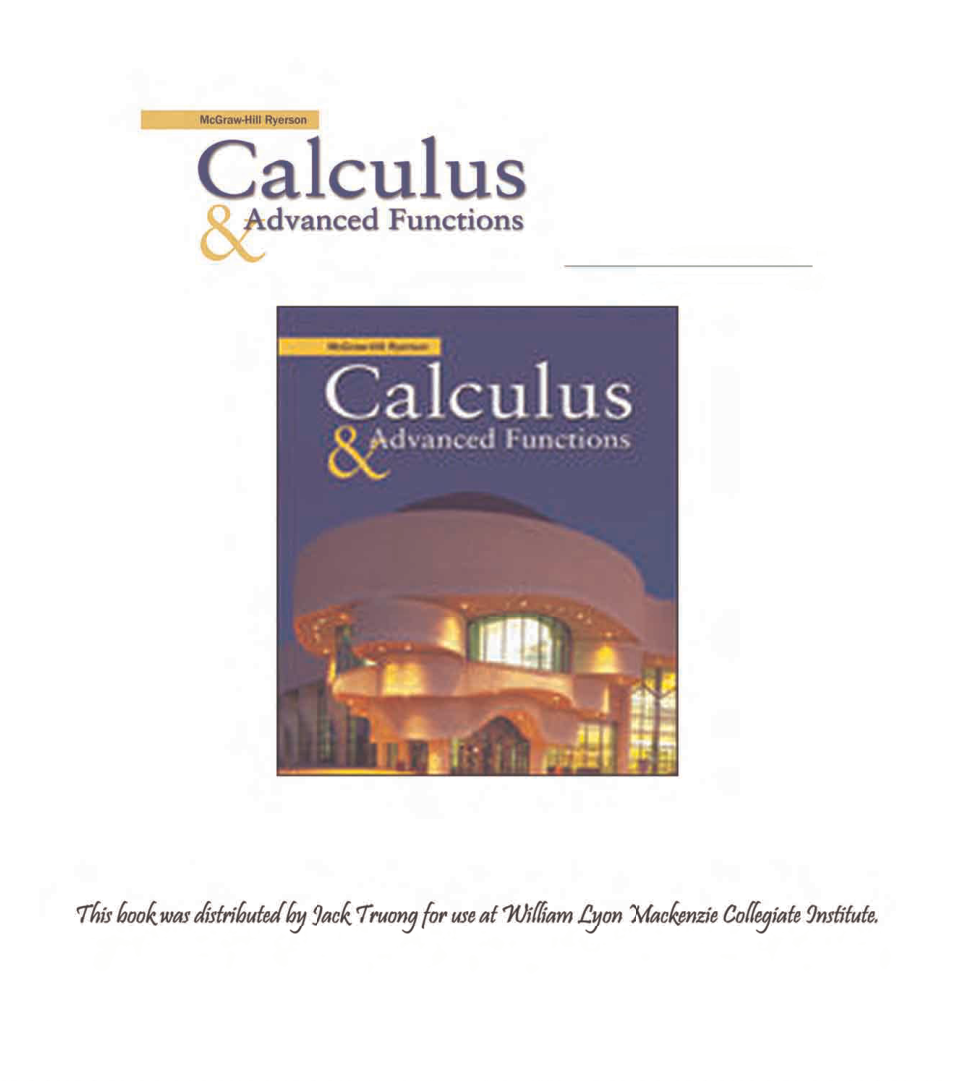

In [224]:
from IPython.display import Image, display

display(
    Image(
        "page_images/page_1.png"
    )
)

In [225]:
from IPython.display import Image, display
import os

files = sorted(os.listdir("page_images"))

for f in files[:10]:
    print(f)

page_1.png
page_10.png
page_11.png
page_12.png
page_13.png
page_14.png
page_15.png
page_16.png
page_17.png
page_18.png


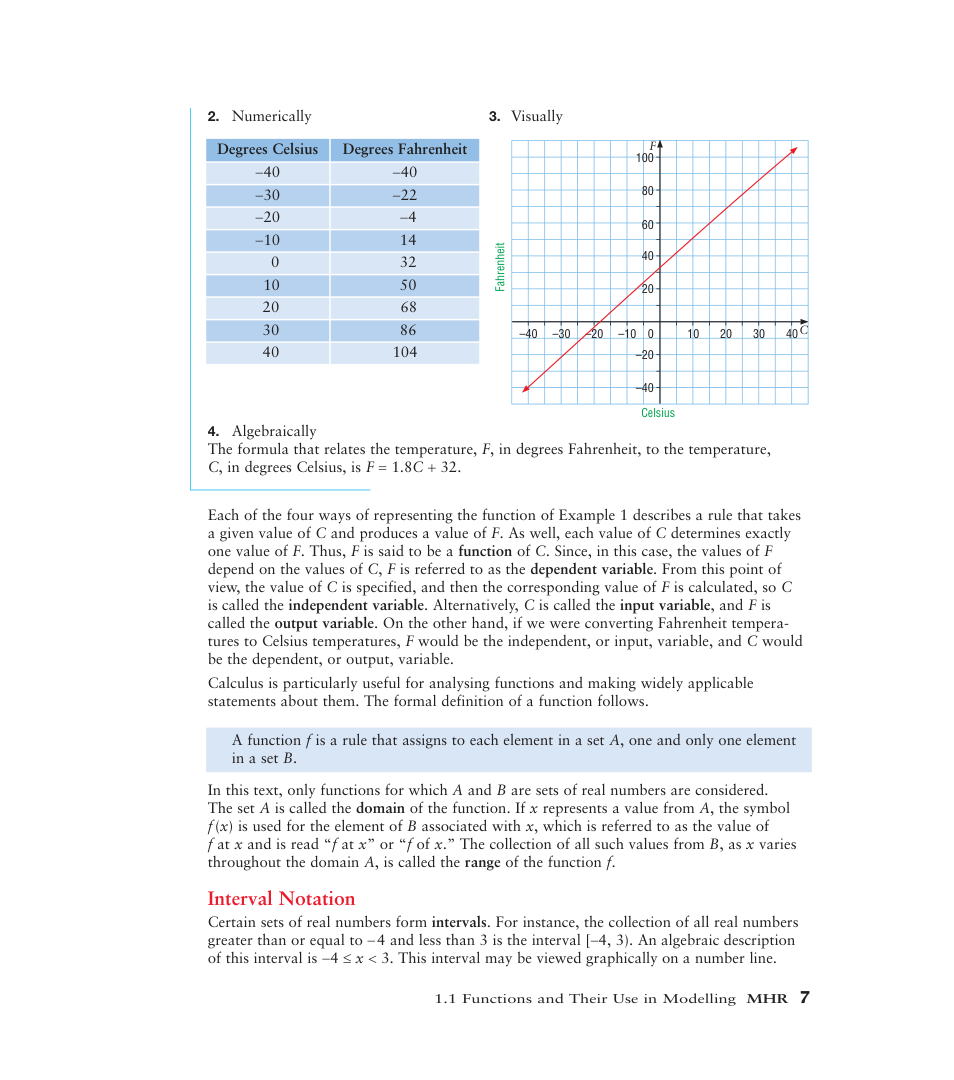

In [226]:
display(Image("page_images/page_7.png"))

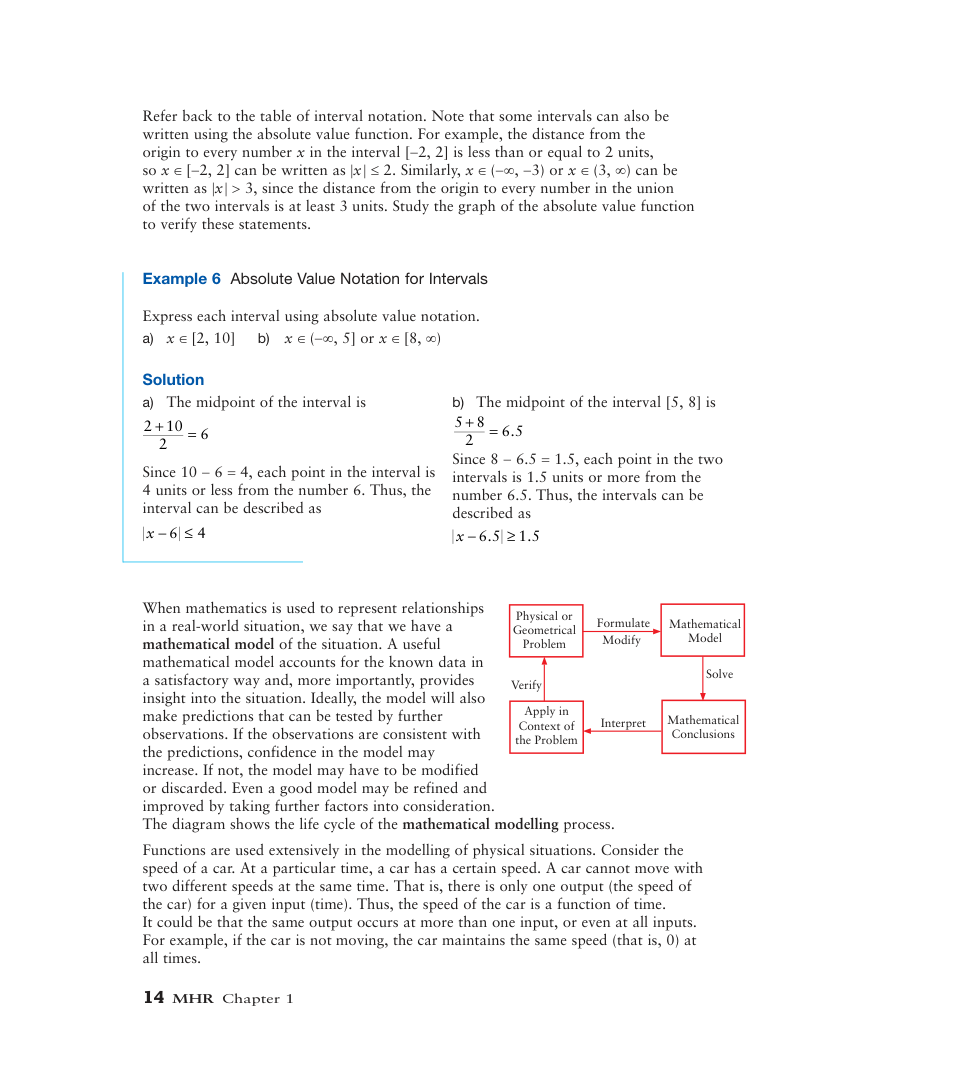

In [227]:
display(Image("page_images/page_14.png"))

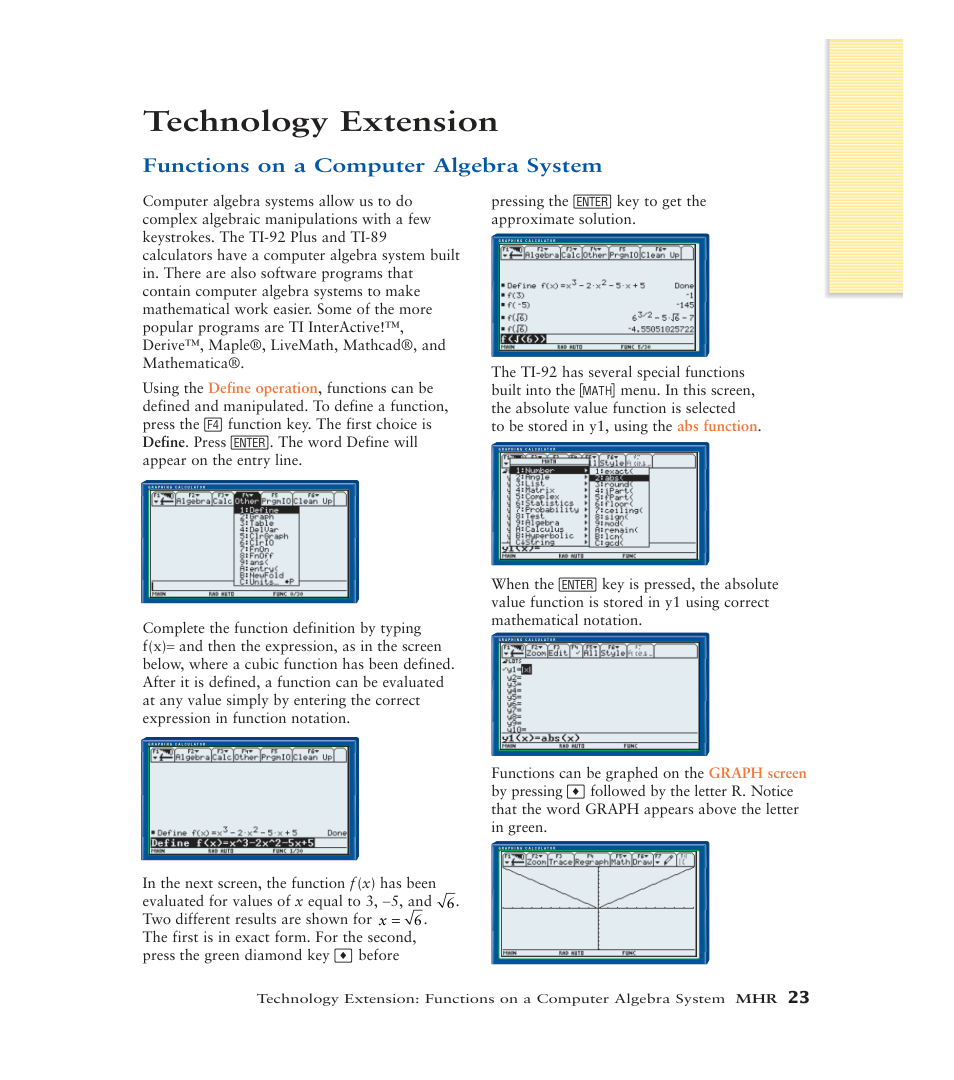

In [228]:
from IPython.display import Image, display

display(Image("page_images/page_23.png"))

In [229]:
question = """
Look at the displayed textbook page.

1. What concept is shown?
2. What graph or equation do you see?
3. Explain one observation from the page.
"""

print(question)


Look at the displayed textbook page.

1. What concept is shown?
2. What graph or equation do you see?
3. Explain one observation from the page.



In [230]:
student_answer = """
The page shows a linear equation.

The graph rises from left to right.

This means the slope is positive.
"""

In [231]:
result = evaluate_answer(
    concept,
    "",
    question,
    student_answer
)

print(result)

{'mastery_score': 88, 'feedback': 'Your answer correctly identifies that the page is about a linear equation and recognizes that the graph rises from left to right, which indicates a positive slope. This shows a solid understanding of how slope relates to the direction of a line on a graph. To improve further, you could be more specific by mentioning the equation form (such as y = mx + b) or describing points, intercepts, or the relationship between slope and rate of change.', 'strengths': ['Correctly identified the concept as a linear equation.', 'Correctly observed that the graph rises from left to right.', "Accurately connected the graph's direction to a positive slope."], 'weaknesses': ['The explanation could include more mathematical detail.', 'Did not mention a specific equation or graph feature such as intercepts.'], 'recommended_practice': ['Practice identifying slope and y-intercept from graphs.', 'Write equations of lines using slope-intercept form.', 'Describe graphs using m

In [232]:
print("Visual Index Entries:", len(visual_index))

print(list(visual_index.keys())[:20])

Visual Index Entries: 27
['Review of function notation and evaluating functions', 'Interpreting graphs, domain, and range', 'Linear equations, slope, and intercepts', 'Equations of lines from points and slopes', 'Quadratic functions and graphing parabolas', 'Completing the square and vertex form', 'Function transformations and symmetry', 'Absolute value functions and interval notation', 'Even and odd functions', 'Mathematical modelling with functions', 'Linear, quadratic, and exponential models', 'Using technology to graph and analyze functions', 'Introduction to polynomial functions', 'Characteristics of cubic and quartic functions', 'Finite differences and degree of polynomials', 'Polynomial operations and simplification', 'Synthetic division and long division of polynomials', 'Remainder theorem and factor theorem', 'Factoring higher-degree polynomials', 'Real and complex roots of polynomial equations']


In [233]:
roadmap = load_roadmap()

for i, item in enumerate(roadmap):
    print(i, item["concept"])

0 Review of function notation and evaluating functions
1 Interpreting graphs, domain, and range
2 Linear equations, slope, and intercepts
3 Equations of lines from points and slopes
4 Quadratic functions and graphing parabolas
5 Completing the square and vertex form
6 Function transformations and symmetry
7 Absolute value functions and interval notation
8 Even and odd functions
9 Mathematical modelling with functions
10 Linear, quadratic, and exponential models
11 Using technology to graph and analyze functions
12 Introduction to polynomial functions
13 Characteristics of cubic and quartic functions
14 Finite differences and degree of polynomials
15 Polynomial operations and simplification
16 Synthetic division and long division of polynomials
17 Remainder theorem and factor theorem
18 Factoring higher-degree polynomials
19 Real and complex roots of polynomial equations
20 Graphing polynomial functions from factored form
21 Polynomial inequalities and sign analysis
22 Building polynomi

In [234]:
for key in visual_index.keys():
    print(key)

Review of function notation and evaluating functions
Interpreting graphs, domain, and range
Linear equations, slope, and intercepts
Equations of lines from points and slopes
Quadratic functions and graphing parabolas
Completing the square and vertex form
Function transformations and symmetry
Absolute value functions and interval notation
Even and odd functions
Mathematical modelling with functions
Linear, quadratic, and exponential models
Using technology to graph and analyze functions
Introduction to polynomial functions
Characteristics of cubic and quartic functions
Finite differences and degree of polynomials
Polynomial operations and simplification
Synthetic division and long division of polynomials
Remainder theorem and factor theorem
Factoring higher-degree polynomials
Real and complex roots of polynomial equations
Graphing polynomial functions from factored form
Polynomial inequalities and sign analysis
Building polynomial models from graphs and zeros
Rates of change and average

In [242]:
def find_images_for_concept(concept, visual_index):

    # exact match
    if concept in visual_index:
        return visual_index[concept]

    # split concept into words
    concept_words = [
        word.lower()
        for word in concept.replace(",", " ")
                          .replace("(", " ")
                          .replace(")", " ")
                          .split()
        if len(word) > 3
    ]

    best_key = None
    best_score = 0

    for key in visual_index.keys():

        score = 0

        key_lower = key.lower()

        for word in concept_words:

            if word in key_lower:
                score += 1

        if score > best_score:
            best_score = score
            best_key = key

    if best_key:

        print(
            "Matched visual concept:",
            best_key
        )

        return visual_index[best_key]

    return []

In [243]:
concept = resume_learning()["concept"]

print(concept)

images = find_images_for_concept(
    concept,
    visual_index
)

print(images)

Equations of lines from points and slopes
[]


In [244]:
for key in visual_index.keys():

    if "slope" in key.lower():
        print(key)
        print(visual_index[key])
        print()

Linear equations, slope, and intercepts
['page_images/page_28.png']

Equations of lines from points and slopes
[]



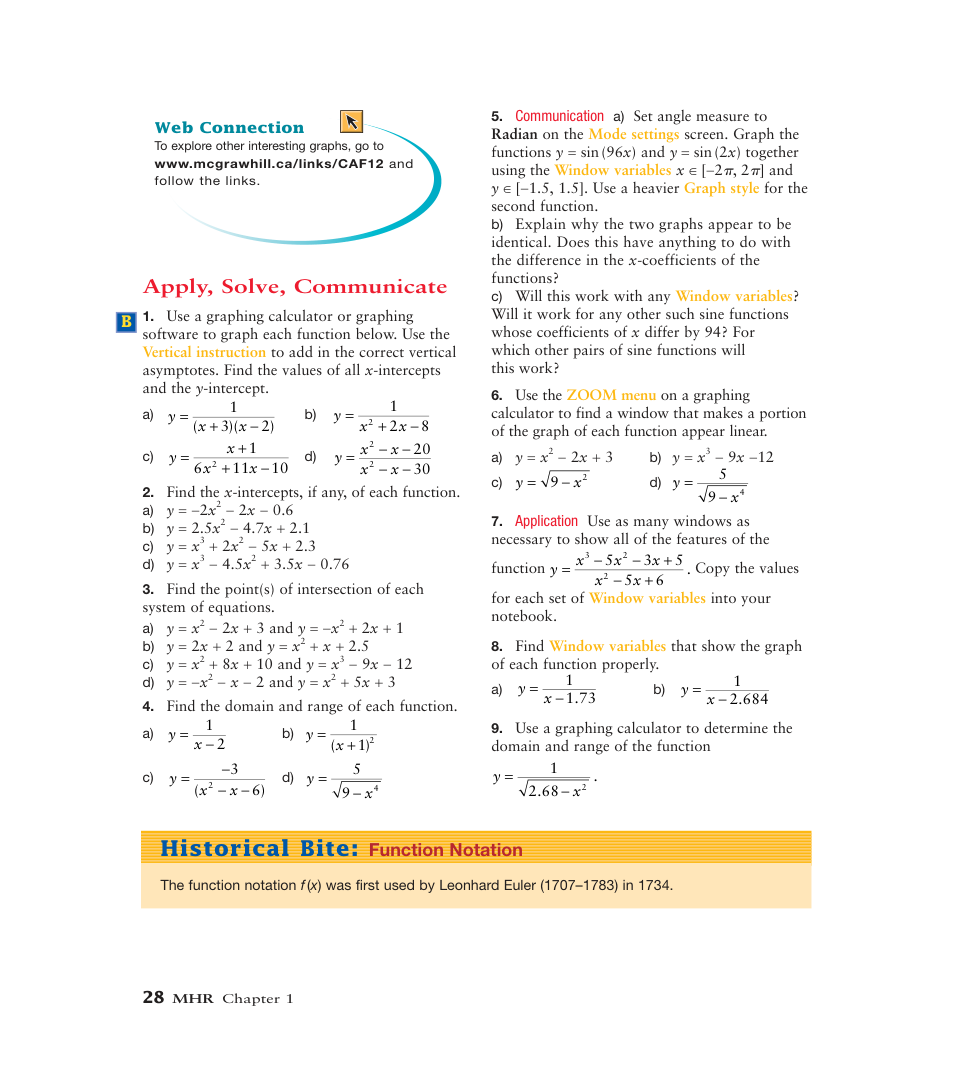

In [246]:
from IPython.display import Image, display

display(
    Image(
        "page_images/page_28.png"
    )
)


In [247]:
if concept in visual_index:
    images = visual_index[concept]
else:
    images = visual_index.get(
        "Linear equations, slope, and intercepts",
        []
    )

In [248]:
for key in visual_index.keys():

    if (
        "slope" in key.lower()
        or
        "line" in key.lower()
    ):
        print(key)

Linear equations, slope, and intercepts
Equations of lines from points and slopes
Linear, quadratic, and exponential models
Introduction to derivatives and tangent lines


In [249]:
import shutil
import os

PROJECT_DIR = "/content/drive/MyDrive/AI_Tutor_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)

files = [
    "app.py",
    "course_roadmap.json",
    "student_profile.json",
    "lesson_cache.json",
    "quiz_cache.json",
    "image_question_cache.json",
    "visual_index.json",
    "grade12math.pdf"
]

for file in files:
    if os.path.exists(file):
        shutil.copy2(
            file,
            os.path.join(PROJECT_DIR, file)
        )
        print("Saved:", file)

Saved: app.py
Saved: course_roadmap.json
Saved: student_profile.json
Saved: lesson_cache.json
Saved: quiz_cache.json
Saved: image_question_cache.json
Saved: visual_index.json
Saved: grade12math.pdf


In [250]:
import shutil
import os

src = "page_images"

dst = "/content/drive/MyDrive/AI_Tutor_Project/page_images"

if os.path.exists(src):

    if os.path.exists(dst):
        shutil.rmtree(dst)

    shutil.copytree(src, dst)

    print("Saved page_images")

Saved page_images


In [251]:
!ls /content/drive/MyDrive/AI_Tutor_Project

app.py			   lesson_cache.json  student_profile.json
course_roadmap.json	   logs.txt	      visual_index.json
grade12math.pdf		   page_images
image_question_cache.json  quiz_cache.json


In [252]:
%cd /content/drive/MyDrive

!zip -r AI_Tutor_Project.zip AI_Tutor_Project


/content/drive/MyDrive
  adding: AI_Tutor_Project/ (stored 0%)
  adding: AI_Tutor_Project/app.py (deflated 67%)
  adding: AI_Tutor_Project/course_roadmap.json (deflated 77%)
  adding: AI_Tutor_Project/student_profile.json (deflated 73%)
  adding: AI_Tutor_Project/lesson_cache.json (deflated 58%)
  adding: AI_Tutor_Project/quiz_cache.json (deflated 59%)
  adding: AI_Tutor_Project/image_question_cache.json (deflated 49%)
  adding: AI_Tutor_Project/visual_index.json (deflated 73%)
  adding: AI_Tutor_Project/grade12math.pdf (deflated 18%)
  adding: AI_Tutor_Project/logs.txt (deflated 31%)
  adding: AI_Tutor_Project/page_images/ (stored 0%)
  adding: AI_Tutor_Project/page_images/page_29.png (deflated 4%)
  adding: AI_Tutor_Project/page_images/page_3.png (deflated 0%)
  adding: AI_Tutor_Project/page_images/page_31.png (deflated 5%)
  adding: AI_Tutor_Project/page_images/page_25.png (deflated 4%)
  adding: AI_Tutor_Project/page_images/page_14.png (deflated 5%)
  adding: AI_Tutor_Project/page_